In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates 
import matplotlib.ticker as ticker 
from matplotlib.axis import Axis 
import datetime as dt
from datetime import datetime, date
#plt.style.use(['science', 'notebook'])
# %matplotlib inline

import time
begin = time.time()

### Le fichier temp03062024.csv est mis à jour par weather_bis.py sur pi4 dans terminal
### A partir de 02/01/2026 10h, weather_ter.py marche en double pour créer le csv temp02012026.csv


In [2]:

#csv_file1 = r"Y:\Documents\temp16122022.csv.old"  # saved 16/12/2022

# 2024-2026
csv_file1 = r"Y:\Documents\temp03062024.csv"

# 2026
#csv_file1 = r"Y:\Documents\temp02012026.csv"

#csv_file2 = r"Z:\Documents\temp16122022.csv"


In [3]:

def read_text(filename):
    f = open(filename, "r")
    text = f.readlines()
    f.close()
    print(text)


def get_data(filename):    
    data = pd.read_csv(filename)
    #data['time'] = pd.to_datetime(data['time'])  #.dt.tz_convert(None)
    #data.info()
    #print(data.tail(5))
    return data

try:
    data = get_data(csv_file1)
except:
    data = get_data(csv_file2)
#data['heure'] = pd.to_datetime(data['time']).dt.strftime('%H:%M') #time
#data['jour'] = pd.to_datetime(data['time']).dt.strftime('%d/%m') #date
len(data), data

(20446,
         temp
 0      13.19
 1      12.20
 2      12.29
 3      12.42
 4      14.54
 ...      ...
 20441  17.18
 20442  17.04
 20443  16.45
 20444  16.99
 20445  18.21
 
 [20446 rows x 1 columns])

In [4]:
def from_csv(csv_file):    
    df = pd.read_csv(csv_file)
    return df

def to_csv(csv_file, df):
    df.to_csv(csv_file, index=False)


<Axes: >

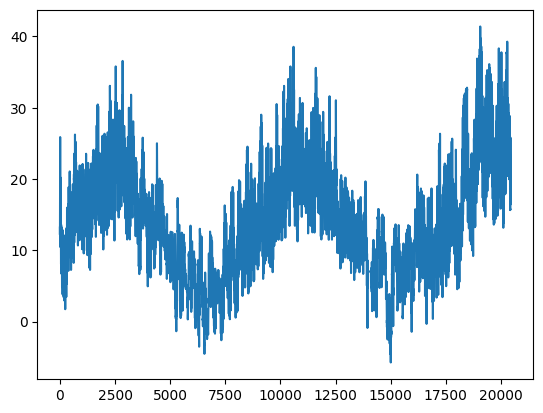

In [5]:
data['temp'].plot()

In [6]:
csv_file1

'Y:\\Documents\\temp03062024.csv'

In [7]:
# convert string to datetime

date_time_str = '16/04/24 07:00:00'   # avant 2026
# décalage car il manque des data sur 5 jours et 6 heures fin 2025
date_time_str = '21/04/24 13:00:00'   # date de début des data 2024-2026
if csv_file1 == r"Y:\Documents\temp02012026.csv":
    date_time_str = '03/01/26 08:00:00'    # début 2026
ref = datetime.strptime(date_time_str, '%d/%m/%y %H:%M:%S')

then = ref + dt.timedelta(hours=len(data))
ref,then

(datetime.datetime(2024, 4, 21, 13, 0), datetime.datetime(2026, 8, 21, 11, 0))

In [8]:
len(data), date_time_str

(20446, '21/04/24 13:00:00')

In [9]:
def mk_date(date_time_str,data):
    # 
    ref = datetime.strptime(date_time_str, '%d/%m/%y %H:%M:%S')
    then = ref + dt.timedelta(hours=len(data))
    return mdates.drange(ref,then,dt.timedelta(hours=1))


In [10]:
hours = mk_date(date_time_str,data)
#len(hours)
dates = [datetime.strftime(h, '%d/%m/%y %H:%M:%S') for h in mdates.num2date(hours)]
#dates
if len(data)<len(hours):
    data['hours']=hours[:-1]
    data['dates']=dates[:-1]
else:
    data['hours']=hours
    data['dates']=dates
data

,temp,hours,dates
0,13.19,19834.541667,21/04/24 13:00:00
1,12.20,19834.583333,21/04/24 14:00:00
2,12.29,19834.625000,21/04/24 15:00:00
3,12.42,19834.666667,21/04/24 16:00:00
4,14.54,19834.708333,21/04/24 17:00:00
...,...,...,...
20441,17.18,20686.250000,21/08/26 06:00:00
20442,17.04,20686.291667,21/08/26 07:00:00
20443,16.45,20686.333333,21/08/26 08:00:00
20444,16.99,20686.375000,21/08/26 09:00:00


In [11]:
data[['dates','temp']]

,dates,temp
0,21/04/24 13:00:00,13.19
1,21/04/24 14:00:00,12.20
2,21/04/24 15:00:00,12.29
3,21/04/24 16:00:00,12.42
4,21/04/24 17:00:00,14.54
...,...,...
20441,21/08/26 06:00:00,17.18
20442,21/08/26 07:00:00,17.04
20443,21/08/26 08:00:00,16.45
20444,21/08/26 09:00:00,16.99


In [12]:
import warnings
warnings.filterwarnings("ignore")


In [13]:
# data des 24 premieres heures
d_24 = data[:24]['temp']
#d_24


In [14]:
# moyenne des premieres 24 heures
m_day = d_24.mean()
m_day

np.float64(19.400000000000016)

In [15]:
# moyenne sur 24 heures depuis le 16/12/2022 9h
mean_all = []
window = 24
h_w = window//2
for l in range(len(data)-window):
    d_24 = data[l:l+window]['temp'].mean()
    mean_all.append(d_24)
x = data[:-window]['hours'].values    
len(mean_all), len(x)

(20422, 20422)

In [16]:
def format_date(space=3):
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))  #('%d/%m\n%H:%M'))
    #plt.gca().xaxis.set_major_locator(mdates.HourLocator(space))
    plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=space*5))
    plt.gcf().autofmt_xdate()
    plt.grid()

Text(0.5, 1.0, 'Moyenne sur 24 heures sur 7 jours')

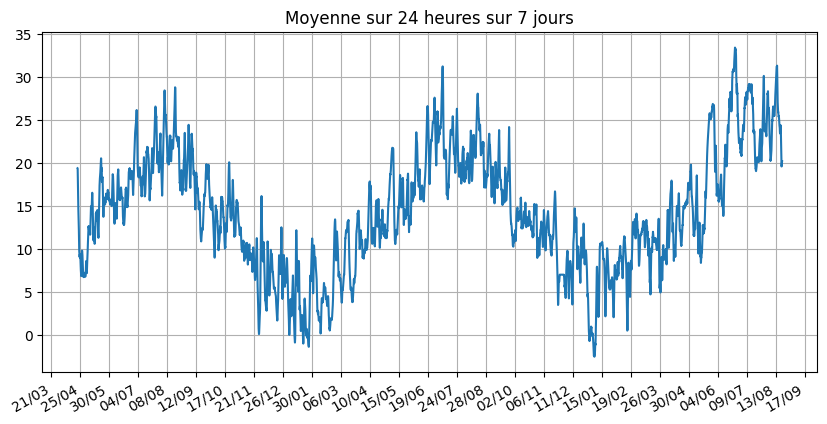

In [17]:
fig, ax = plt.subplots()
fig.set_size_inches(10, 5)
plt.plot(x,mean_all, markersize=1)
jours = 7
format_date(jours*24) # jours x 24 h
plt.title(f'Moyenne sur 24 heures sur {jours} jours') #depuis le 16/12/2022')
#plt.grid()

In [18]:
today = datetime.now()
diff = today - ref
diff

datetime.timedelta(days=851, seconds=78768, microseconds=607264)

In [19]:
days = diff.days + diff.seconds/(24*3600)
days = int(days)


In [20]:
# moyenne depuis le 16/12/22
slice = int(days*24)
h = data.tail(slice).hours
t = data.tail(slice).temp
#h, t
ref,today,days


(datetime.datetime(2024, 4, 21, 13, 0),
 datetime.datetime(2026, 8, 21, 10, 52, 48, 607264),
 851)

In [21]:
temp = data['temp']
moyenne = data['temp'].mean()
moyenne

np.float64(14.334615572728184)

np.float64(14.334615572728184)

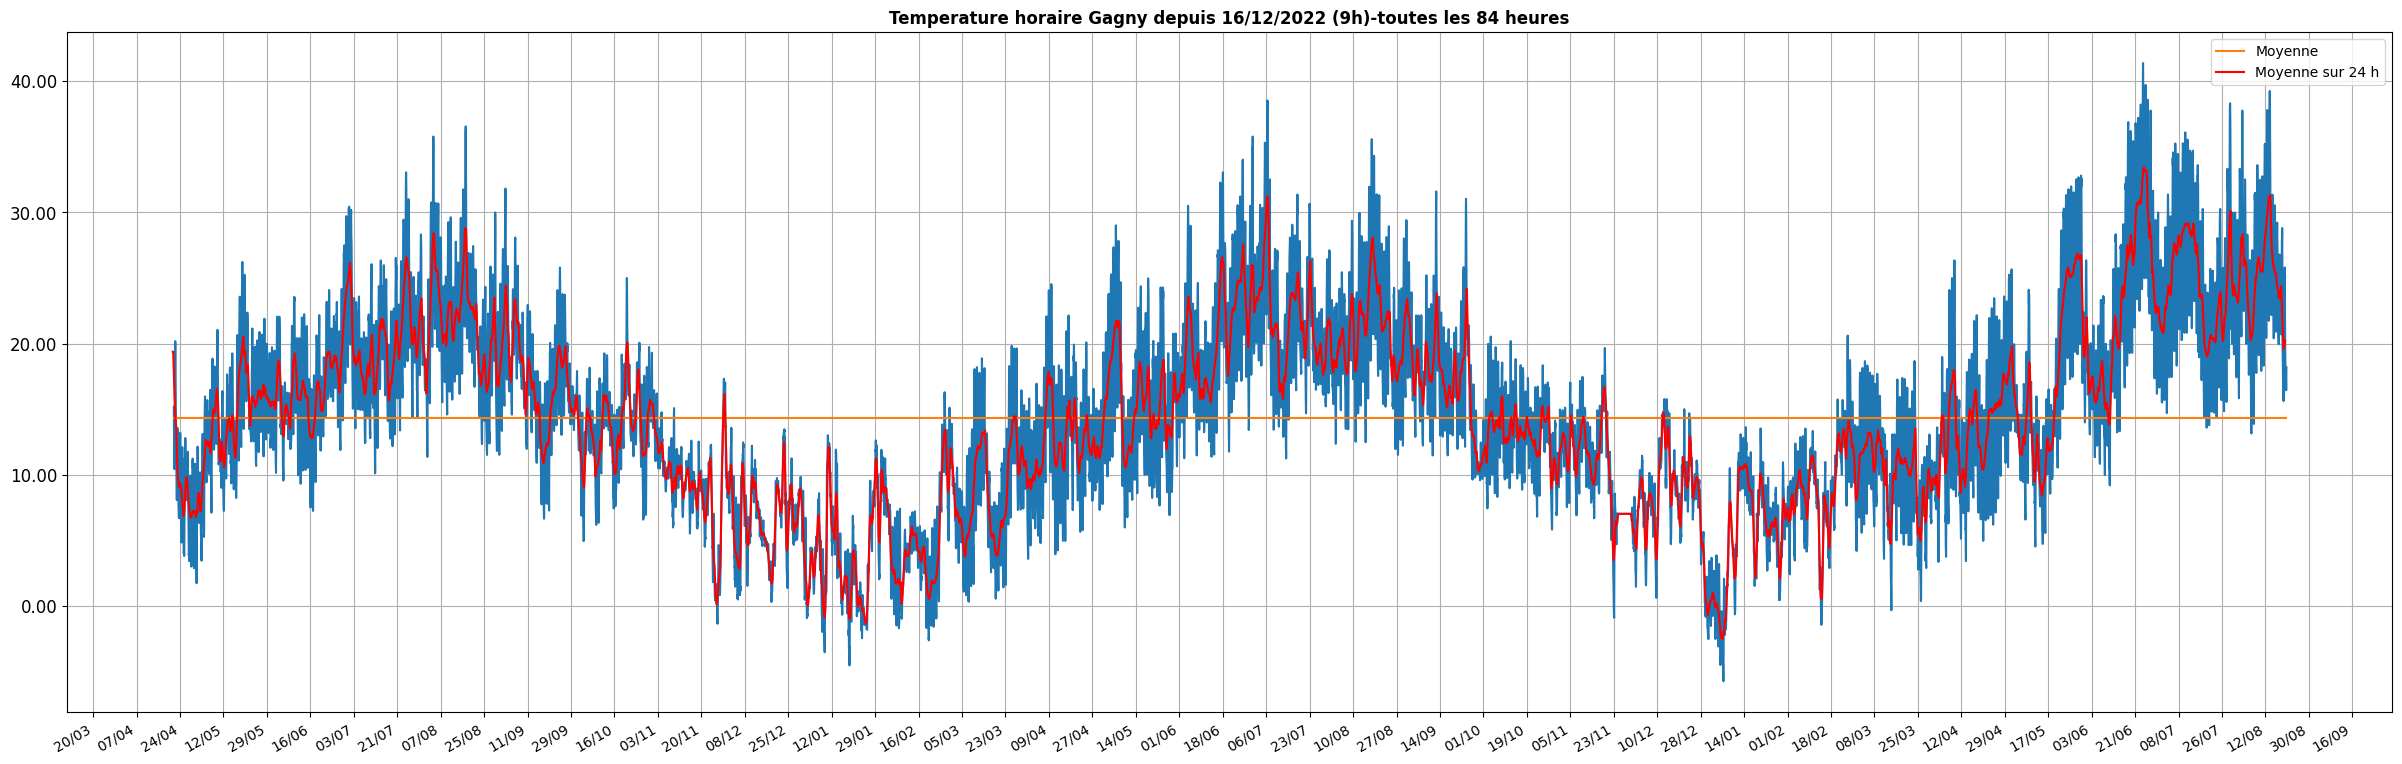

In [22]:
interval = 84
fig, ax = plt.subplots()
fig.set_size_inches(30, 10)
#plot = data['temp'].plot(figsize=(12,6))
plt.plot(h,t)
h1 = h.head(1)
h2 = h.tail(1)
plt.plot((h1,h2),(moyenne, moyenne),label='Moyenne')
plt.plot(hours[h_w:len(data)-h_w],mean_all,'r-',label=f'Moyenne sur {window} h')
#plt.plot(hours,temp)
plt.title(f"Temperature horaire Gagny depuis 16/12/2022 (9h)-toutes les {interval} heures",fontweight ='bold')


plt.legend()
#ax.set_xticks(hours)
ax.set_xticklabels(hours,fontsize=10)
#ax.set_yticks()
ax.set_yticklabels(temp,fontsize=12)

# Y_axis
formatter = ticker.FormatStrFormatter('%1.2f')
Axis.set_major_formatter(ax.yaxis, formatter)
format_date(12*7)
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m:%H:%M'))
# plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=interval))
# plt.gcf().autofmt_xdate()
# plt.grid()
moyenne


In [23]:
data['variation']=data['temp'].diff()
data

,temp,hours,dates,variation
0,13.19,19834.541667,21/04/24 13:00:00,NaN
1,12.20,19834.583333,21/04/24 14:00:00,-0.99
2,12.29,19834.625000,21/04/24 15:00:00,0.09
3,12.42,19834.666667,21/04/24 16:00:00,0.13
4,14.54,19834.708333,21/04/24 17:00:00,2.12
...,...,...,...,...
20441,17.18,20686.250000,21/08/26 06:00:00,-0.24
20442,17.04,20686.291667,21/08/26 07:00:00,-0.14
20443,16.45,20686.333333,21/08/26 08:00:00,-0.59
20444,16.99,20686.375000,21/08/26 09:00:00,0.54


In [24]:
today

datetime.datetime(2026, 8, 21, 10, 52, 48, 607264)

<Axes: >

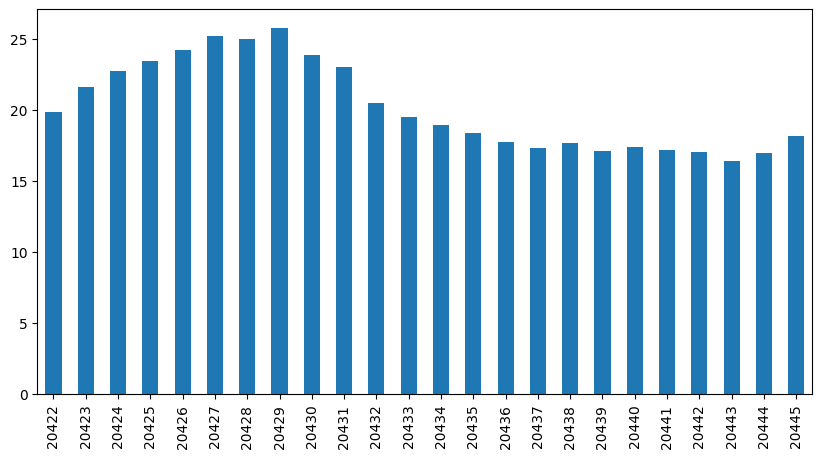

In [25]:
data.tail(24)['temp'].plot.bar(figsize=(10,5))

In [26]:
data

,temp,hours,dates,variation
0,13.19,19834.541667,21/04/24 13:00:00,NaN
1,12.20,19834.583333,21/04/24 14:00:00,-0.99
2,12.29,19834.625000,21/04/24 15:00:00,0.09
3,12.42,19834.666667,21/04/24 16:00:00,0.13
4,14.54,19834.708333,21/04/24 17:00:00,2.12
...,...,...,...,...
20441,17.18,20686.250000,21/08/26 06:00:00,-0.24
20442,17.04,20686.291667,21/08/26 07:00:00,-0.14
20443,16.45,20686.333333,21/08/26 08:00:00,-0.59
20444,16.99,20686.375000,21/08/26 09:00:00,0.54


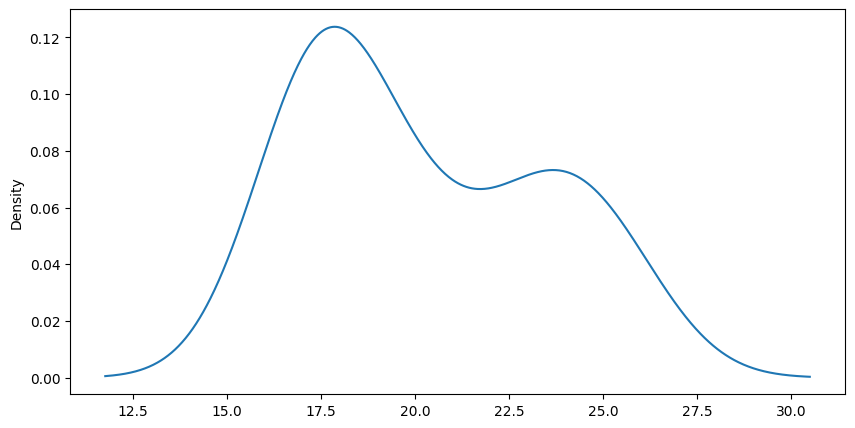

In [27]:
span = 24
try:
    data.tail(span)['temp'].plot.kde(figsize=(10,5))
    #data['temp'].plot.kde(figsize=(10,5))
except:
    pass

<Axes: ylabel='Frequency'>

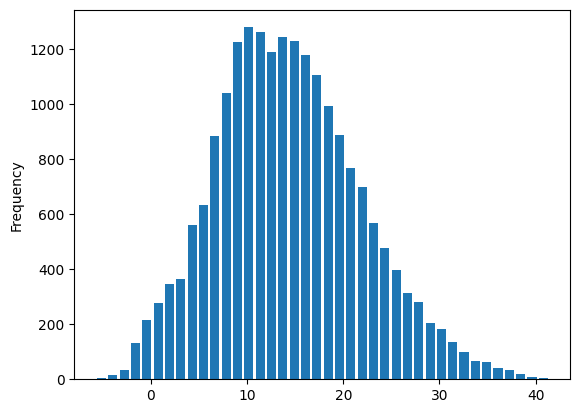

In [28]:
data['temp'].plot.hist(bins=40,rwidth=0.8) #,histtype='step')


In [29]:
#data['temp'].plot.kde(xlim=(-10,40)) #,logy=True)

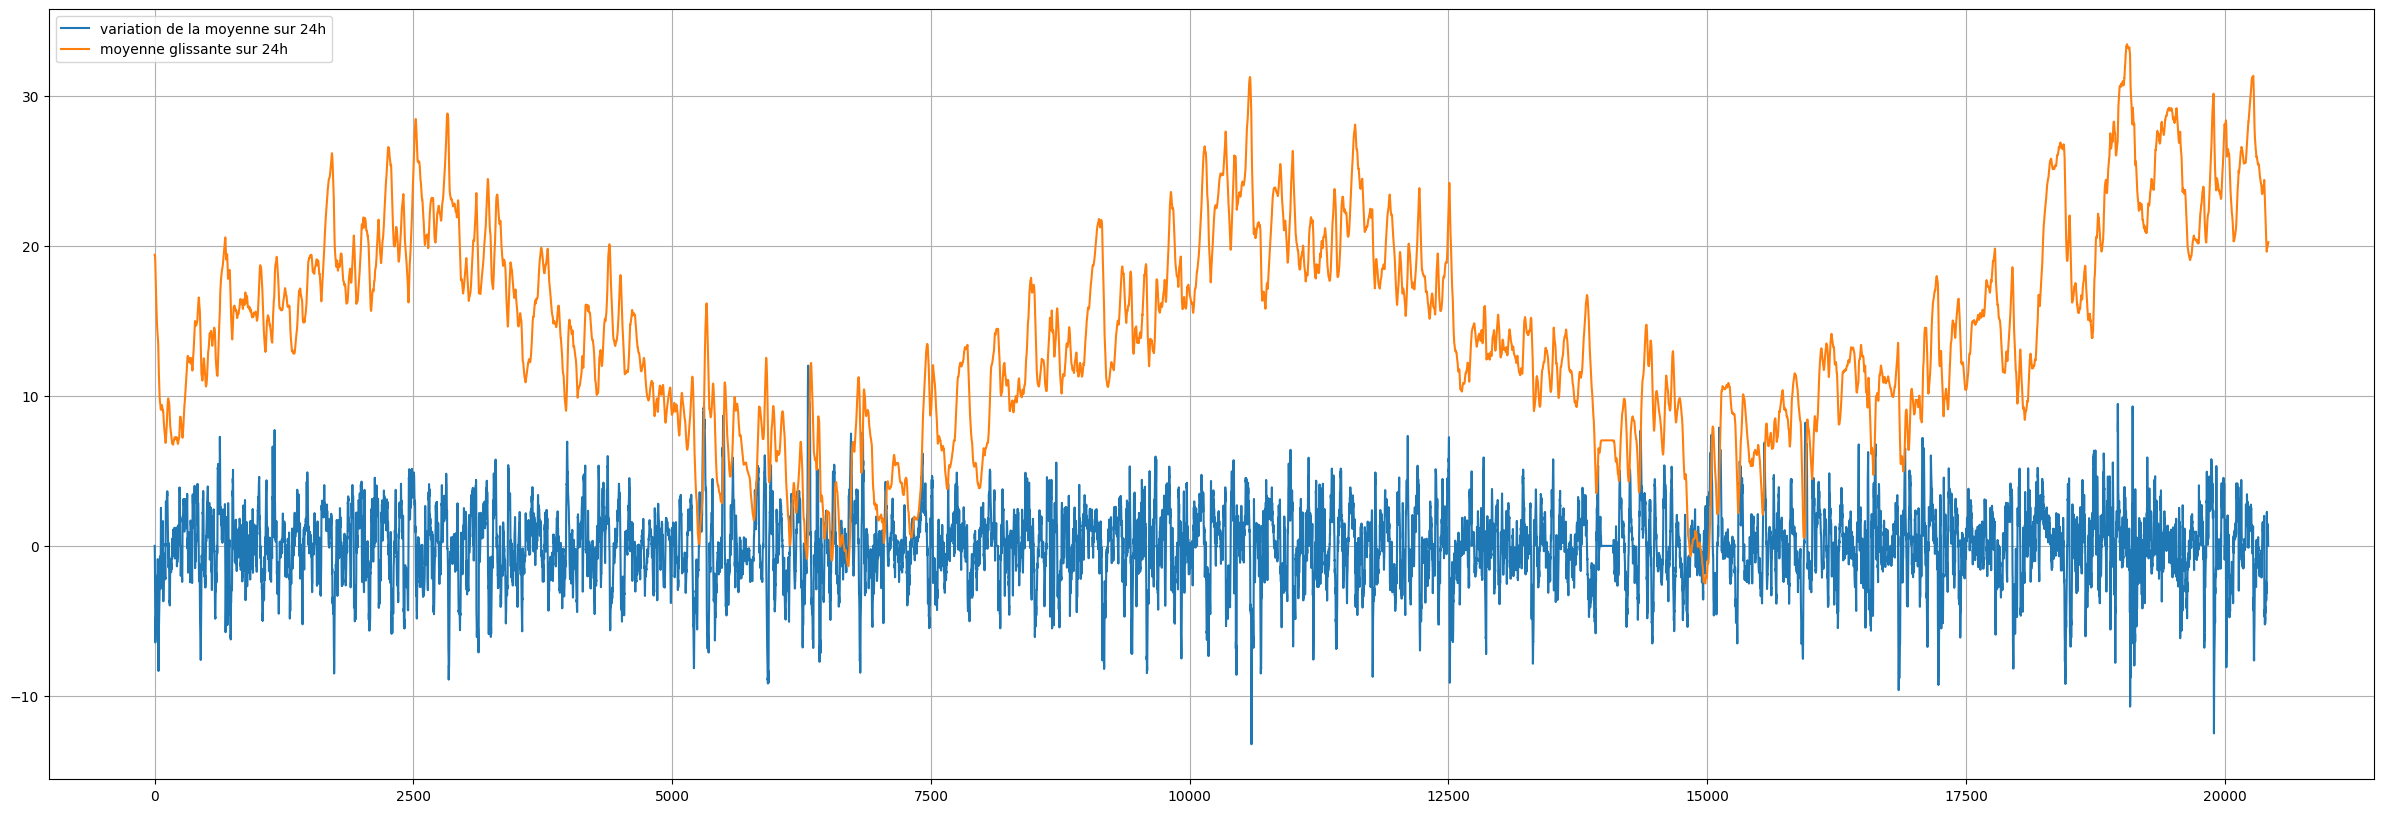

In [30]:
# variation horaire
fig, ax = plt.subplots()
fig.set_size_inches(30, 10)
delta = np.diff(mean_all)
facteur = 20   # amplifie la variation delta
plt.plot(facteur*delta,label='variation de la moyenne sur 24h')
plt.plot(mean_all,label='moyenne glissante sur 24h')
plt.legend()
plt.grid()

## Définir une fenêtre de visualisation : days

In [31]:
# fenetre de visualisation
days = 15
#days = int(len(data)/24)  # sur toute la liste de data


# xAxis interval
if days>30:
    interval = 72
elif days>15:
    interval = 24
elif days>7:
    interval = 12
else:
    interval = 6


In [32]:
window, days, interval

(24, 15, 12)

In [33]:
# moyenne avec une fenetre de 24h (window) calculé sur le nombre de jours=days 
mean_days = []
max_days = []
min_days = []
ecart_days = []

slice = int(days*24) # last days
#hours[-slice:],temp[-slice:]
h = data.tail(slice).hours
t = data.tail(slice).temp
#h.iloc[0]
start = datetime.now() - dt.timedelta(days=days)
window_start = start.strftime("%d/%m/%Y, %H:%M:%S")

#window = 24
#h_w = int(window/2)
for l in range(len(t)-window):
    d_24 = t[l:l+window].mean()
    M_24 = t[l:l+window].max()
    m_24 = t[l:l+window].min()
    mean_days.append(d_24)
    max_days.append(M_24)
    min_days.append(m_24)
    ecart_days.append(M_24-m_24)
moyenne = t.mean()
#moyenne  # moyenne sur la fenetre de visualisation
len(h[:-24]),len(max_days), len(min_days),len(ecart_days),window

(336, 336, 336, 336, 24)

In [34]:
h

20086    20671.458333
20087    20671.500000
20088    20671.541667
20089    20671.583333
20090    20671.625000
             ...     
20441    20686.250000
20442    20686.291667
20443    20686.333333
20444    20686.375000
20445    20686.416667
Name: hours, Length: 360, dtype: float64

In [35]:
datetime.now()

datetime.datetime(2026, 8, 21, 10, 53, 24, 521712)

In [36]:
window_start

'06/08/2026, 10:53:23'

In [37]:
def select(days):
    # moyenne sur la fenetre days
    mean_days = []
    max_days = []
    min_days = []
    ecart_days = []
    # fenetre de visualisation
    #days = int(len(data)/24)  # sur toute la liste de data
    #days = 30
    slice = int(days*24) # last days
    #hours[-slice:],temp[-slice:]
    h = data.tail(slice).hours
    t = data.tail(slice).temp
    #h.iloc[0]
    #start = datetime.now() - dt.timedelta(days=days)
    #window_start = start.strftime("%d/%m/%Y, %H:%M:%S")
    
    #window = 24
    #h_w = int(window/2)
    for l in range(len(t)-window):
        d_24 = t[l:l+window].mean()
        M_24 = t[l:l+window].max()
        m_24 = t[l:l+window].min()
        ecart_days.append(M_24 - m_24)
        mean_days.append(d_24)
        max_days.append(M_24)
        min_days.append(m_24)
    moyenne = t.mean()
    #moyenne  # moyenne sur la fenetre de visualisation
    return mean_days,max_days,min_days,ecart_days,moyenne


mean_d,max_d,min_d,ecart_d,moyenne = select(days)
moyenne

np.float64(24.974500000000024)

In [38]:
mean_d,max_d,min_d,ecart_d,moyenne = select(15)
len(mean_d),moyenne

(336, np.float64(24.974500000000024))

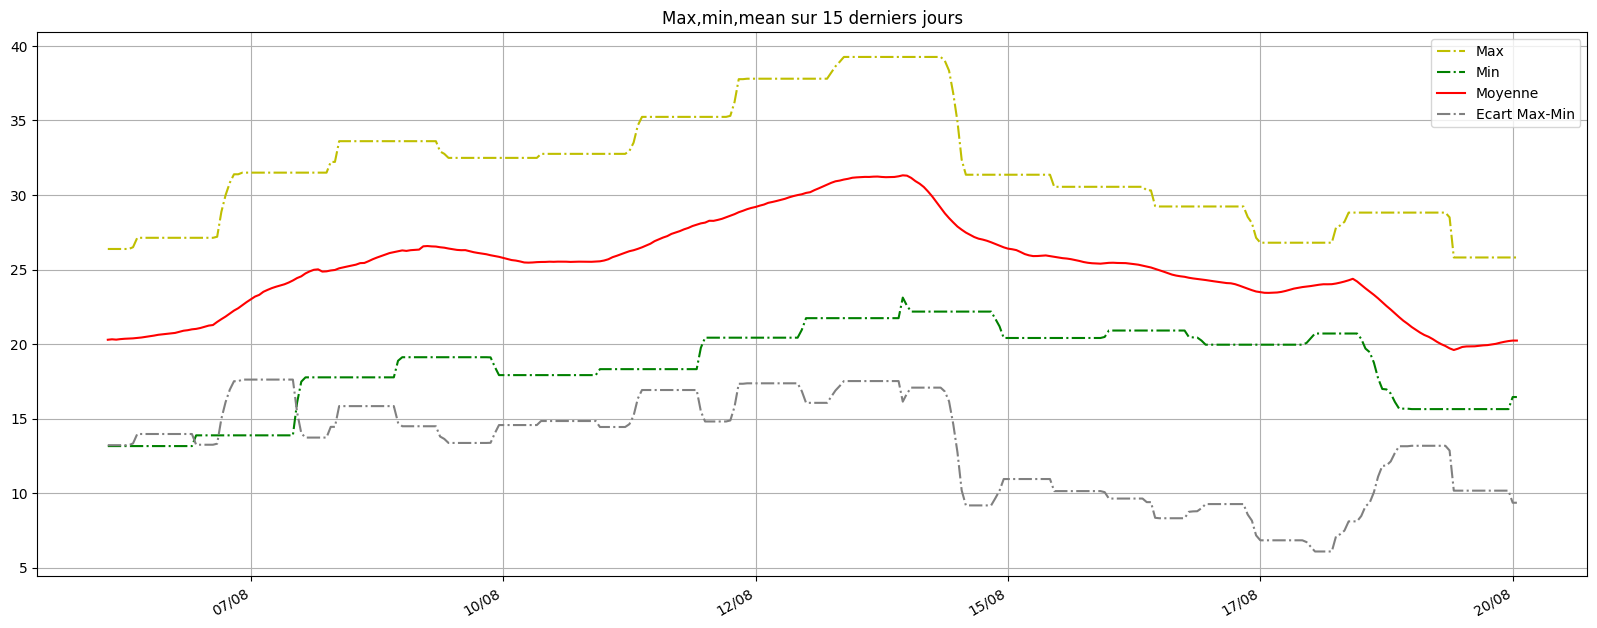

In [39]:
fig, ax = plt.subplots()
# the size of A4 paper
fig.set_size_inches(20, 8)
x = h[:-24]
plt.title(f"Max,min,mean sur {days} derniers jours")
plt.plot(x,max_days,"y-.",label="Max")
plt.plot(x,min_days,"g-.",label="Min")
plt.plot(x,mean_days,'r',label="Moyenne")
plt.plot(x,ecart_days,'-.',color='grey',label="Ecart Max-Min")
#plt.plot(t[l:l+window])
format_date(interval)
plt.legend()

In [40]:
#delta = [j-i for i, j in zip(mean_week[:-1], mean_week[1:])]
delta = np.diff(mean_days)
#delta

## Delta/days des moyennes 24h avec un glissement d'une heure

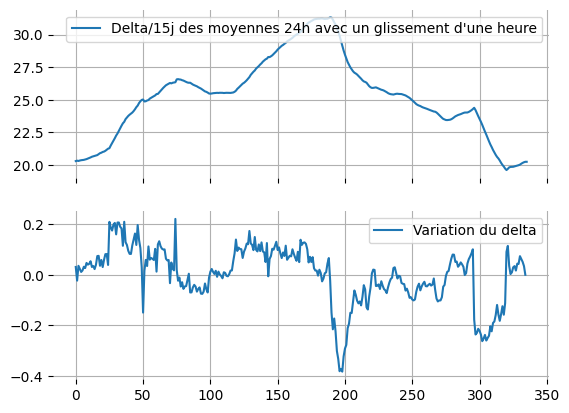

In [41]:
#fig,ax =plt.subplots(nrows=2)
#fig,ax =plt.subplots(nrows=2, sharex=True)
fig,ax =plt.subplots(nrows=2, sharex=True, subplot_kw=dict(frameon=False))
ax[0].plot(mean_days,label='Delta/'+str(days)+'j des moyennes 24h avec un glissement d\'une heure')
ax[1].plot(delta,label=('Variation du delta'))
ax[0].grid()
ax[1].grid()
ax[0].legend()
ax[1].legend()


In [42]:
def local_min_max(liste):
    """
    Trouve les minima et maxima locaux d'une liste.

    Args:
    liste: La liste à analyser.

    Returns:
    Les listes max et min.
    """

    max = []
    min = []

    if liste[0] > liste[1]:
        max.append(liste[0])
    elif liste[0] <= liste[1] :
        min.append(liste[0])

    for i in range(1, len(liste) - 1):
        if liste[i] > liste[i - 1] and liste[i] >= liste[i + 1]:
            max.append(liste[i])
        elif liste[i] <= liste[i - 1] and liste[i] < liste[i + 1]:
            min.append(liste[i])

    return max, min


liste = [10, 11, 15, 12, 9, 7, 8, 10, 13, 15, 18, 16, 12, 10, 7, 5, 6, 11, 14, 14]
max, min = local_min_max(liste)

max,min

([15, 18, 14], [10, 7, 5])

In [43]:
# graphical output...
from pylab import sign, diff # type: ignore


In [44]:
# plot graph with local max and min
def plot_data(x,data,lw=3):
    # find the indexes of maximas and the minimas
    #a = diff(sign(diff(data))).nonzero()[0] + 1 # local min+max
    b = (diff(sign(diff(data))) > 0).nonzero()[0] + 1 # local min
    c = (diff(sign(diff(data))) < 0).nonzero()[0] + 1 # local max
    print(b,len(b),c,len(c))
    # plot the curve
    plt.plot(x,data,lw=lw)
    #plot the maximas
    for v in b:
        plt.plot(x[v], data[v], "ob")
    #plot the minimas
    for v in c:
        plt.plot(x[v], data[v], "or")
    plt.grid()


[ 5 15] 2 [ 2 10 18] 3


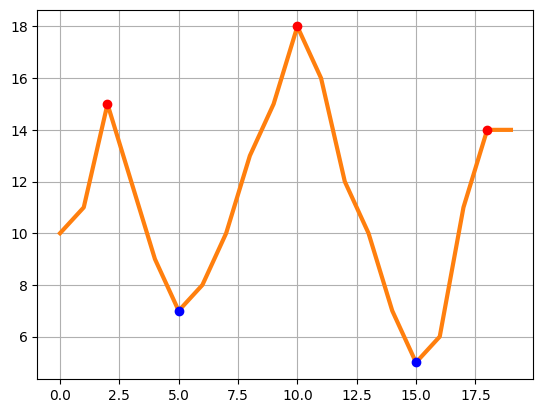

In [45]:
x = range(len(liste))
plt.plot(liste)
plot_data(x,liste)

In [46]:
jours = 7
data['heures']=[k.split(' ')[1].split(':')[0] for k in data.dates]
data['jours']=[k.split(' ')[0] for k in data.dates]

data.tail(24*jours)[['jours','heures','temp','variation']]

,jours,heures,temp,variation
20278,14/08/26,11,31.27,1.97
20279,14/08/26,12,34.28,3.01
20280,14/08/26,13,36.80,2.52
20281,14/08/26,14,38.22,1.42
20282,14/08/26,15,38.63,0.41
...,...,...,...,...
20441,21/08/26,06,17.18,-0.24
20442,21/08/26,07,17.04,-0.14
20443,21/08/26,08,16.45,-0.59
20444,21/08/26,09,16.99,0.54


In [47]:
_min_ = round(data.tail(24*jours).temp.min(),2)
_max_ = round(data.tail(24*jours).temp.max(),2)

In [48]:
_max_ - _min_

np.float64(23.619999999999997)

In [49]:
window_start

'06/08/2026, 10:53:23'

## Main graph

(np.float64(24.974500000000024), 15)

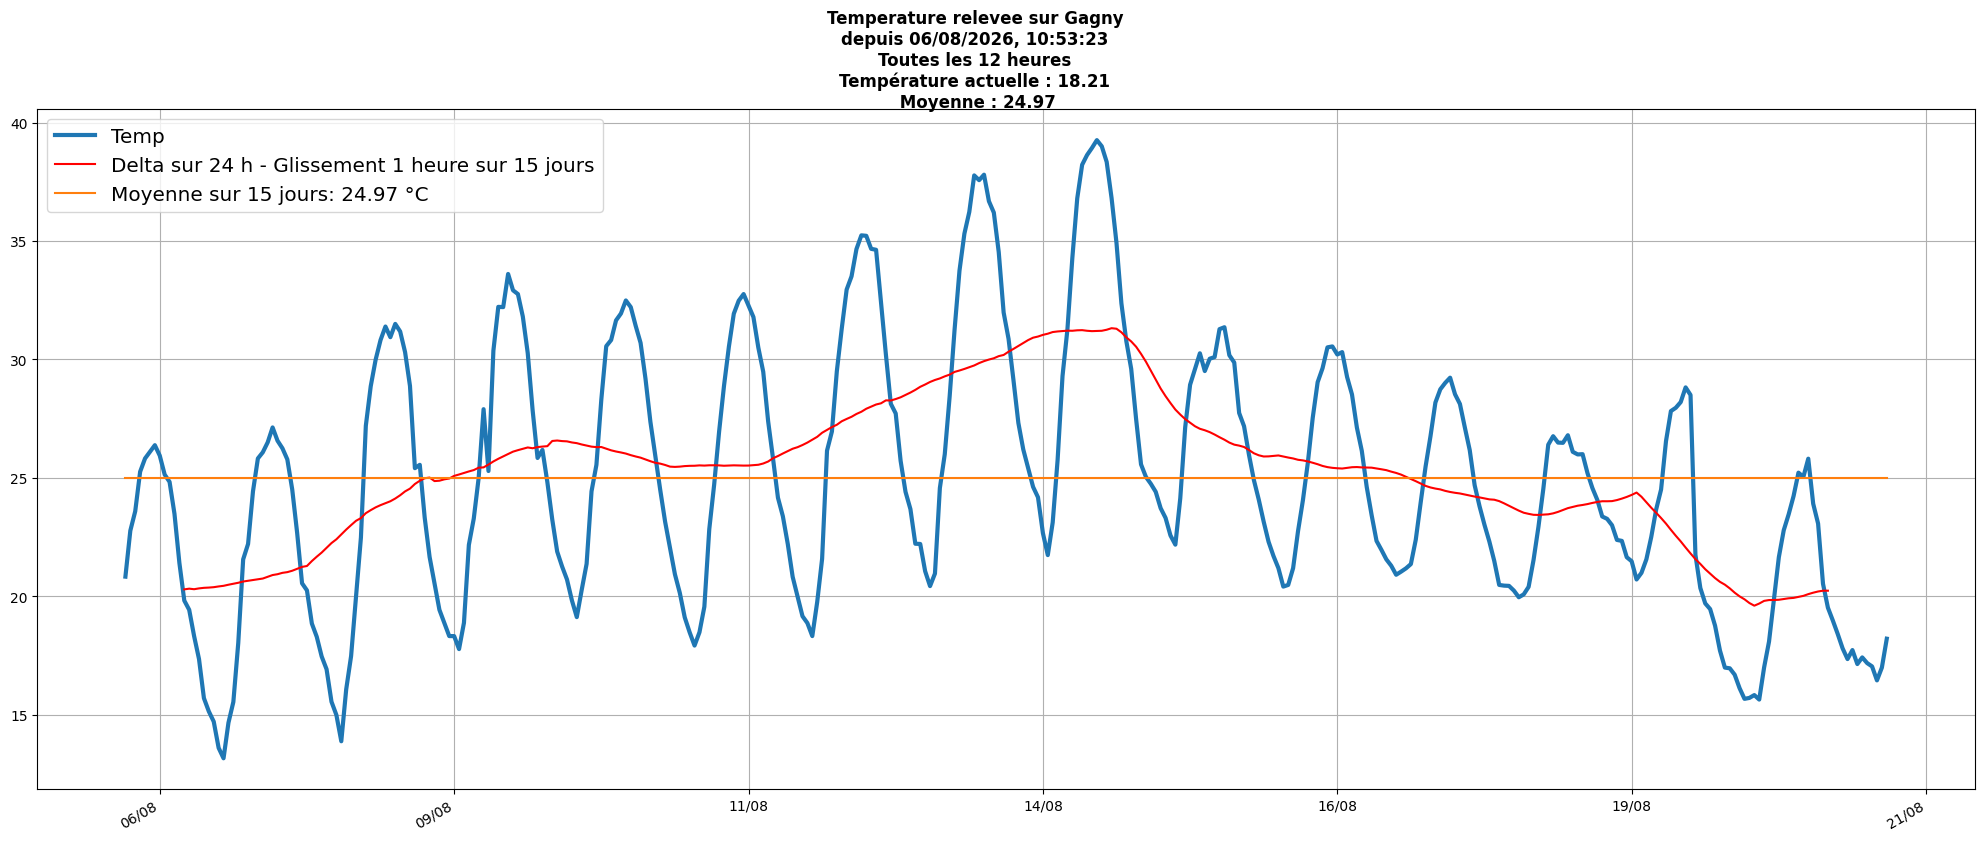

In [50]:
fig, ax = plt.subplots()
# the size of A4 paper
fig.set_size_inches(25, 10)
ax.set_xticklabels(hours,fontsize=10)
fig.suptitle(f"Temperature relevee sur Gagny\n\
depuis {window_start}\n\
Toutes les {interval} heures\nTempérature actuelle : {round(t.tail(1).values[0],2)}\n Moyenne : {round(moyenne,2)}", fontsize = 12, fontweight ='bold') 
#ax.xaxis.set_major_locator(mdates.DayLocator()) 
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m\n%H:%M'))
# plt.gca().xaxis.set_major_locator(mdates.HourLocator(range(0, 24, interval))) #interval=6))
# plt.gcf().autofmt_xdate()
format_date(interval)
plt.plot(h,t,label='Temp',lw=3)
plt.plot(h[h_w:len(t)-h_w],mean_days,'r-',label=f'Delta sur {window} h - Glissement 1 heure sur {days} jours')
h1 = h.head(1)
h2 = h.tail(1)
moy = round(moyenne,2)
plt.plot((h1,h2),(moyenne, moyenne),label=f'Moyenne sur {days} jours: {moy} °C')
#plt.grid()
plt.legend(loc=2,fontsize='x-large')
#plt.title('Current temp : '+str(current.temp)+' °C')

moyenne,days

In [51]:
data.tail(5)[['heures','temp','variation']]

,heures,temp,variation
20441,06,17.18,-0.24
20442,07,17.04,-0.14
20443,08,16.45,-0.59
20444,09,16.99,0.54
20445,10,18.21,1.22


In [52]:
def area(df,dx=1):
    return (sum(df[:len(df)-1])+sum(df[1:len(df)]))*dx/2
df=[0,1]
area(df,1)

0.5

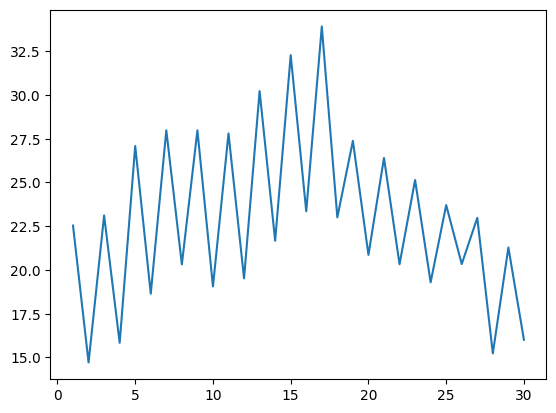

In [53]:
s = list(t)
# area under temperature
a=[]
for k in range(0,len(s),h_w):
    a.append(area(s[k:k+h_w])/h_w)
x = np.array(range(1,len(a)+1))
plt.plot(x,a)

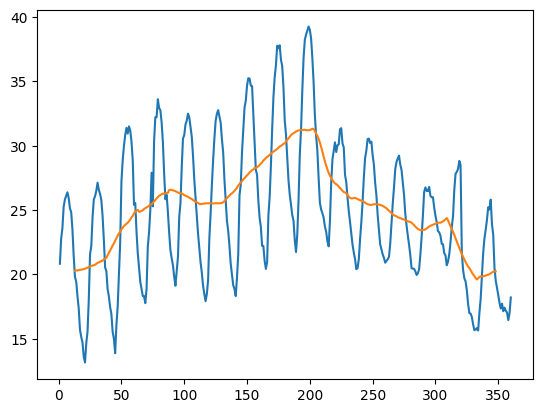

In [54]:
x = np.array(range(1,len(t)+1))
area(t)

plt.plot(x,t)
plt.plot(x[h_w:len(x)-h_w],mean_days)

(1.9500000000000002, [<matplotlib.lines.Line2D at 0x1bc2e351a90>])

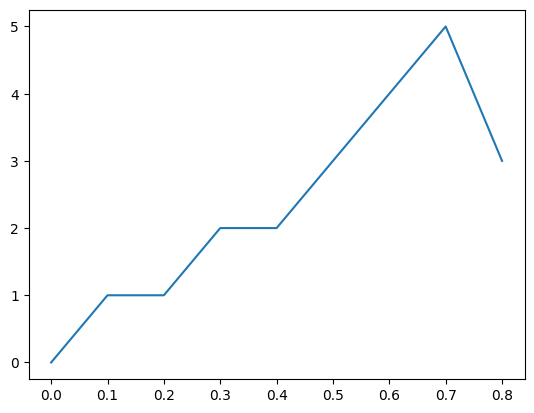

In [55]:
df = [0,1,1,2,2,3,4,5,3]
dx = .1
x = np.array(range(len(df)))
area(df,dx),plt.plot(x*dx,df)


(-0.35000000000000003, [<matplotlib.lines.Line2D at 0x1bc2e3ccf50>])

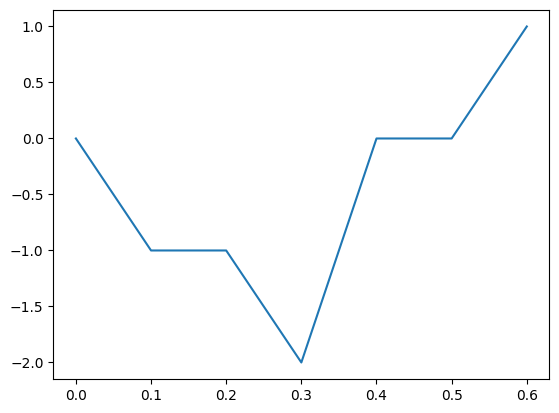

In [56]:
# valeurs négatives
dx = 0.1
df = [0,-1,-1,-2,0,0,1]
x = np.array(range(len(df)))
area(df,dx),plt.plot(x*dx,df)

In [57]:
n = data.tail(1)['dates'].values[0]
n, type(n)

('21/08/26 10:00:00', str)

In [58]:
def days_hours_minutes(td):
    return td.days, td.seconds//3600, (td.seconds//60)%60

In [59]:
savefig = False
ref = '07/08/25 07:00:00'
datetime_object = datetime.strptime(ref, '%d/%m/%y %H:%M:%S')
datetime_object

datetime.datetime(2025, 8, 7, 7, 0)

In [60]:
def get_next_save_date(ref_date, current_date=None):
    global savefig
    """
    Calculate the next save date (every 7 days from reference date).
    
    Args:
        ref_date (datetime): The reference start date
        current_date (datetime, optional): Date to check from. Defaults to now.
    
    Returns:
        savefig : update flag
        datetime: Next save date
    """
    if current_date is None:
        current_date = datetime.now()
    
    delta = current_date - ref_date
    days_since_last_save = delta.days % 7
    print(days_since_last_save)
    if days_since_last_save == 0:
        print("Save the figure")
        savefig = True
        return current_date
    else:
        return current_date + dt.timedelta(days=(7 - days_since_last_save))


In [61]:
# Example usage
next_save = get_next_save_date(datetime_object)
print(savefig)
print(f"Next save will be on: {next_save.strftime('%d/%m/%y')}")
td = datetime.now() - datetime_object
if savefig:
    print("Save figure")
else:
    print("No saving today")

1
False
Next save will be on: 27/08/26
No saving today


In [62]:
ref, td, td.days%7, days_hours_minutes(td)

('07/08/25 07:00:00',
 datetime.timedelta(days=379, seconds=14011, microseconds=980317),
 1,
 (379, 3, 53))

In [63]:
end = time.time()
print(end - begin)

57.03266167640686


In [64]:
savefig

False

In [65]:
data.tail(15)  # 02/01/2026 22h index 14918 à recopier vers temp02012026.csv

,temp,hours,dates,variation,heures,jours
20431,23.07,20685.833333,20/08/26 20:00:00,-0.84,20,20/08/26
20432,20.53,20685.875000,20/08/26 21:00:00,-2.54,21,20/08/26
20433,19.52,20685.916667,20/08/26 22:00:00,-1.01,22,20/08/26
20434,18.98,20685.958333,20/08/26 23:00:00,-0.54,23,20/08/26
20435,18.41,20686.000000,21/08/26 00:00:00,-0.57,00,21/08/26
20436,17.80,20686.041667,21/08/26 01:00:00,-0.61,01,21/08/26
20437,17.35,20686.083333,21/08/26 02:00:00,-0.45,02,21/08/26
20438,17.73,20686.125000,21/08/26 03:00:00,0.38,03,21/08/26
20439,17.14,20686.166667,21/08/26 04:00:00,-0.59,04,21/08/26
20440,17.42,20686.208333,21/08/26 05:00:00,0.28,05,21/08/26


# Température depuis 15 jours par heure

In [66]:
today = datetime.now()
today_str = today.strftime('%d/%m/%y %H:%M:%S')

In [67]:
data.tail(1)["dates"].values[0].split(':')[0], today_str.split(':')[0]


('21/08/26 10', '21/08/26 10')

### test de validité de data !

#### vérification de ligne de données manquantes

In [68]:
difference_heures = int(data.tail(1)["dates"].values[0].split(' ')[1].split(':')[0]) - int(today_str.split(' ')[1].split(':')[0])   
difference_heures

0

In [69]:
assert data.tail(1)["dates"].values[0].split(':')[0] == today_str.split(':')[0]

In [70]:
jours = 15

In [71]:
# liste des températures sur une même plage horaire de 24h des 7 derniers jours
data_24_list = [list([data.tail(24*t).temp.head(24).values]) for t in range(jours, 0, -1)]
data_24_list

[[array([20.83, 22.77, 23.59, 25.26, 25.82, 26.1 , 26.38, 25.94, 25.14,
         24.83, 23.48, 21.41, 19.82, 19.43, 18.32, 17.35, 15.7 , 15.14,
         14.71, 13.6 , 13.16, 14.66, 15.54, 18.03])],
 [array([21.56, 22.21, 24.43, 25.82, 26.08, 26.5 , 27.13, 26.57, 26.25,
         25.78, 24.51, 22.68, 20.55, 20.25, 18.85, 18.29, 17.46, 16.92,
         15.55, 14.99, 13.88, 16.07, 17.48, 19.98])],
 [array([22.48, 27.2 , 28.87, 29.99, 30.82, 31.39, 30.94, 31.5 , 31.18,
         30.31, 28.88, 25.41, 25.55, 23.32, 21.66, 20.55, 19.43, 18.88,
         18.32, 18.32, 17.77, 18.88, 22.17, 23.28])],
 [array([25.  , 27.9 , 25.29, 30.37, 32.22, 32.21, 33.61, 32.92, 32.76,
         31.81, 30.27, 27.85, 25.84, 26.18, 24.82, 23.24, 21.89, 21.26,
         20.71, 19.83, 19.12, 20.27, 21.37, 24.43])],
 [array([25.55, 28.31, 30.56, 30.82, 31.65, 31.94, 32.49, 32.21, 31.42,
         30.7 , 29.19, 27.37, 25.93, 24.5 , 23.15, 22.04, 20.93, 20.14,
         19.11, 18.48, 17.92, 18.48, 19.56, 22.83])],
 [array([2

### moyenne sur la même plage de 24h sur ...

In [72]:
print(jours, 'jours')

15 jours


In [73]:
# Add all arrays element-wise
sum_array = np.sum(data_24_list, axis=0)

# Divide by jours to get mean
mean_array = sum_array / jours

print("Sum array:", sum_array)
print("Mean array:", mean_array)

Sum array: [[368.43 401.12 423.1  444.8  453.45 461.43 465.92 463.87 449.67 437.56
  417.68 389.77 372.21 357.4  339.41 325.08 312.75 303.83 296.53 288.25
  280.64 289.59 308.71 339.62]]
Mean array: [[24.562      26.74133333 28.20666667 29.65333333 30.23       30.762
  31.06133333 30.92466667 29.978      29.17066667 27.84533333 25.98466667
  24.814      23.82666667 22.62733333 21.672      20.85       20.25533333
  19.76866667 19.21666667 18.70933333 19.306      20.58066667 22.64133333]]


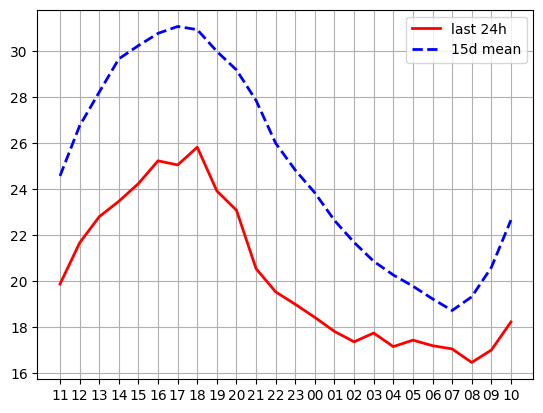

In [74]:
lw = 1
all = False
for t in range(jours,0,-1):
    #if t==1: lw=4
    if t==1:
        plt.plot(data.tail(24*t).heures.head(24),data.tail(24*t).temp.head(24),lw=lw+1,label='last 24h',c='red')
        plt.plot(range(24),mean_array[0],lw=lw+1,label='15d mean',c='blue',ls='--')
    elif all:
        plt.plot(range(24),data_24_list[t-1][0],lw=lw,label=-t)
plt.legend()
plt.grid()

### courbes de températures journalières superposées 
### 15 jours


In [75]:
jours

15

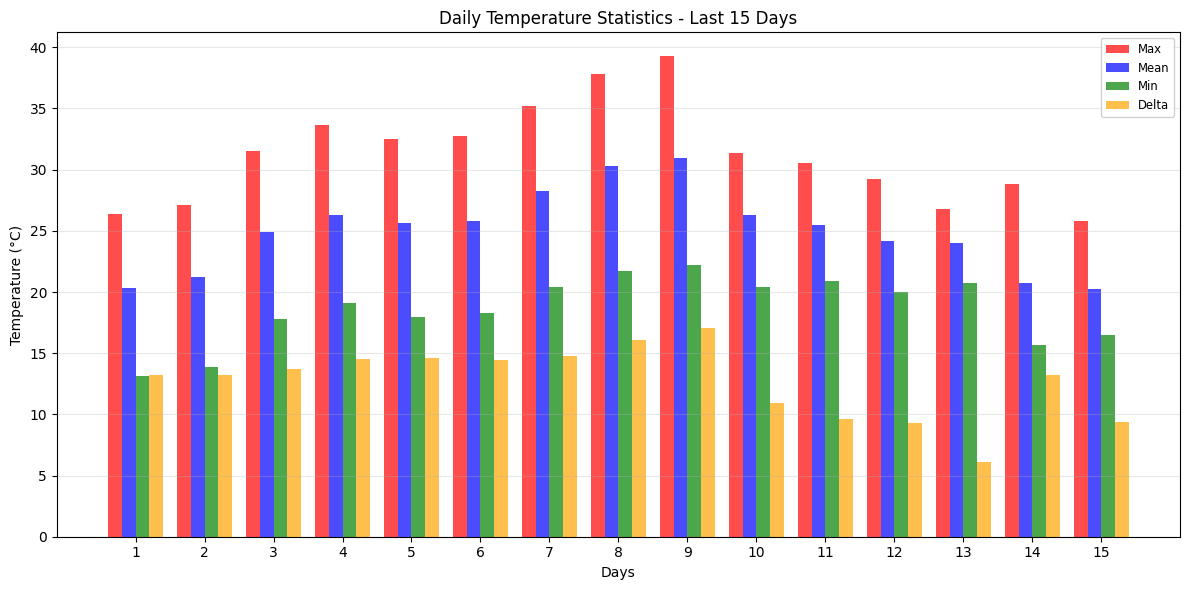

In [76]:
# Create a summary dataframe with daily statistics
df1 = pd.DataFrame({
    'high': [data.tail(24*t).temp.head(24).max() for t in range(jours, 0, -1)],
    'low': [data.tail(24*t).temp.head(24).min() for t in range(jours, 0, -1)],
    'moy': [data.tail(24*t).temp.head(24).mean() for t in range(jours, 0, -1)],
    'delta': [data.tail(24*t).temp.head(24).max() - data.tail(24*t).temp.head(24).min() for t in range(jours, 0, -1)]
})

# Plot the daily statistics
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(df1))
width = 0.2

ax.bar(x_pos - width*1.5, df1['high'], width, label='Max', color='red', alpha=0.7)
ax.bar(x_pos - width/2, df1['moy'], width, label='Mean', color='blue', alpha=0.7)
ax.bar(x_pos + width/2, df1['low'], width, label='Min', color='green', alpha=0.7)
ax.bar(x_pos + width*1.5, df1['delta'], width, label='Delta', color='orange', alpha=0.7)

ax.set_xlabel('Days')
ax.set_ylabel('Temperature (°C)')
ax.set_title(f'Daily Temperature Statistics - Last {jours} Days')
ax.set_xticks(x_pos)
ax.set_xticklabels(range(1, len(df1)+1))
ax.legend()
ax.legend(fontsize='small', loc='best', framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 15 days temperature

Next save date: 27/08/2026 10:53


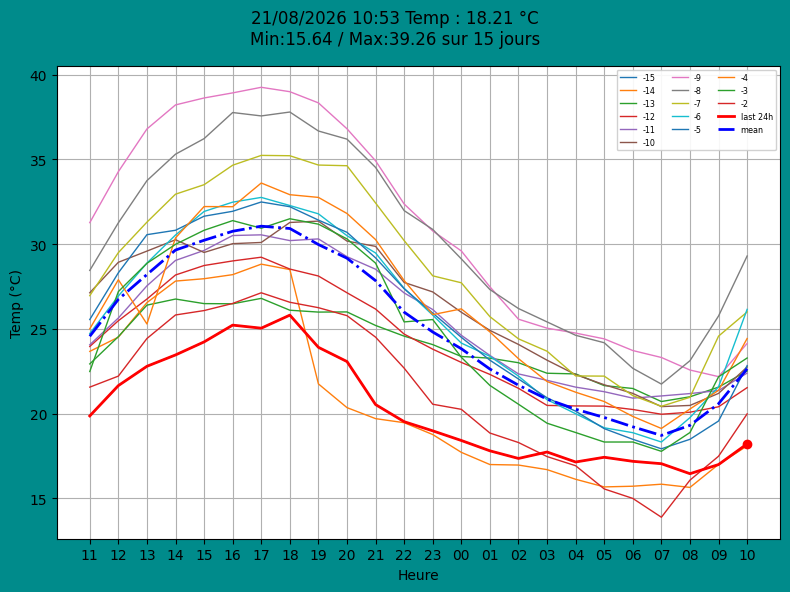

In [77]:
fig, ax = plt.subplots(figsize=(8, 6),facecolor='darkcyan')
#lw = 1
datetime_object = datetime.now()
for t in range(jours,0,-1):
    #if t==1: lw=4
    x = data.tail(24*t).heures.head(24)
    if t==1:
        plt.plot(x,data.tail(24*t).temp.head(24),lw=lw+1,label='last 24h',c='red')
        #plt.plot(x,data_24_list[t-1][0],lw=lw+1,label=-t,c='red')
        plt.plot(x,mean_array[0],lw=lw+1,label='mean',c='blue',ls='-.')
    else:
        #plt.plot(x,data.tail(24*t).temp.head(24),lw=lw,label=-t)
        plt.plot(x,data_24_list[t-1][0],lw=lw,label=-t)

plt.plot(data.tail(1).heures,data.tail(1).temp,'ro')
fig.suptitle(f"{datetime_object.strftime('%d/%m/%Y %H:%M')} Temp : {round(data.tail(1).temp.values[0],2)} °C\nMin:{_min_} / Max:{_max_} sur {jours} jours")
plt.xlabel(f"Heure")
plt.ylabel("Temp (°C)")
plt.grid()
# Valid font size are xx-small, x-small, small, medium, large, x-large, xx-large, larger, smaller, None
plt.legend(fontsize='xx-small', loc='best', ncol=3,framealpha=0.9)

#savefig = True
# save figure if needed
if savefig:
    fig_filename = next_save.strftime('%Y%m%d') + '_7daystemp.png'
    plt.savefig(fig_filename)
    print('Fig saved')
else:
    print('Next save date:', next_save.strftime('%d/%m/%Y %H:%M'))

plt.tight_layout()
plt.show()

In [78]:
data['temp'].tail(24*jours).describe()

count    360.000000
mean      24.974500
std        5.520287
min       13.160000
25%       20.925000
50%       24.570000
75%       28.892500
max       39.260000
Name: temp, dtype: float64

<Axes: ylabel='Density'>

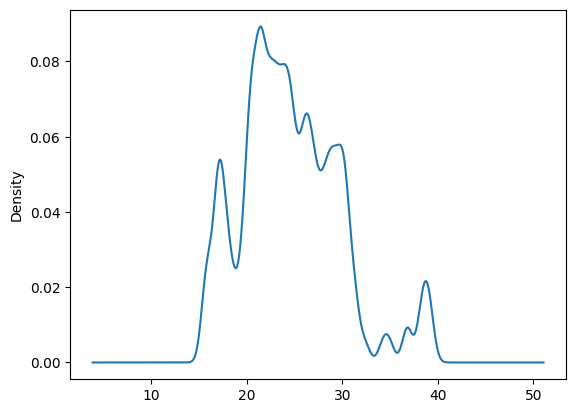

In [79]:
_7days = data['temp'].tail(24*7)
#_7days.hist(bins=20, width=0.5, alpha=0.7)
_7days.plot.kde(bw_method=0.1)


<Axes: >

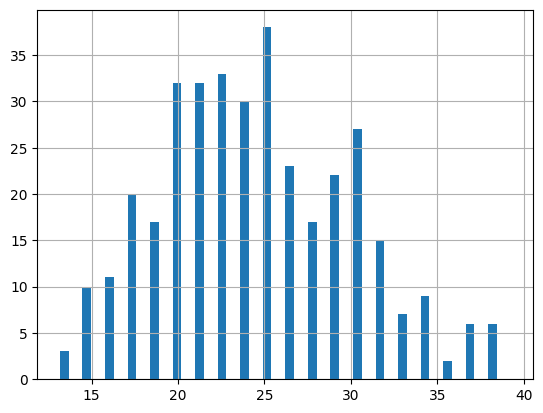

In [80]:
_7days = data['temp'].tail(24*jours)
_7days.hist(bins=20,width=0.5)

In [81]:
print('Min:', _7days.min(), ', Max:', _7days.max(), ', Mean:', _7days.mean())

Min: 13.160000000000023 , Max: 39.26000000000005 , Mean: 24.974500000000024


In [82]:
t=7
max_, min_ = np.max(list(data.tail(24*t).temp.head(24))), np.min(list(data.tail(24*t).temp.head(24)))
print(max_,min_)

39.26000000000005 22.180000000000007


In [83]:
df_jours=data.tail(24*7)
df

[0, -1, -1, -2, 0, 0, 1]

In [84]:
df_jours.groupby('jours')['temp'].mean()

jours
14/08/26    36.123846
15/08/26    27.330417
16/08/26    25.694583
17/08/26    24.661667
18/08/26    23.447083
19/08/26    23.304583
20/08/26    19.853333
21/08/26    17.429091
Name: temp, dtype: float64

<Axes: xlabel='jours'>

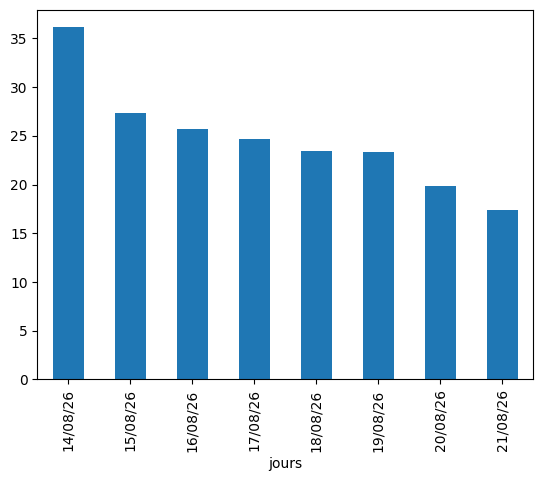

In [85]:
df_jours.groupby('jours')['temp'].mean().plot(kind='bar')

In [86]:
csv_file1

'Y:\\Documents\\temp03062024.csv'

# Save to CSV

In [87]:
save = False
# save to csv 
if save : 
    if csv_file1 == r"Y:\Documents\temp03062024.csv":
        csv_file = r"../data_temp03062024.csv"  
    else:
        csv_file = r"../data_temp02012026.csv"  # 02/01/2026 22h
    to_csv(csv_file, data)

In [88]:
# how to stop here

class StopExecution(Exception):
    def _render_traceback_(self):
        return []
#raise StopExecution

#raise
#assert(False)
#raise KeyboardInterrupt
#ext  # create an error

import this
#dir(list)
#dir(str)

The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!


# how to label on top of a bar plot

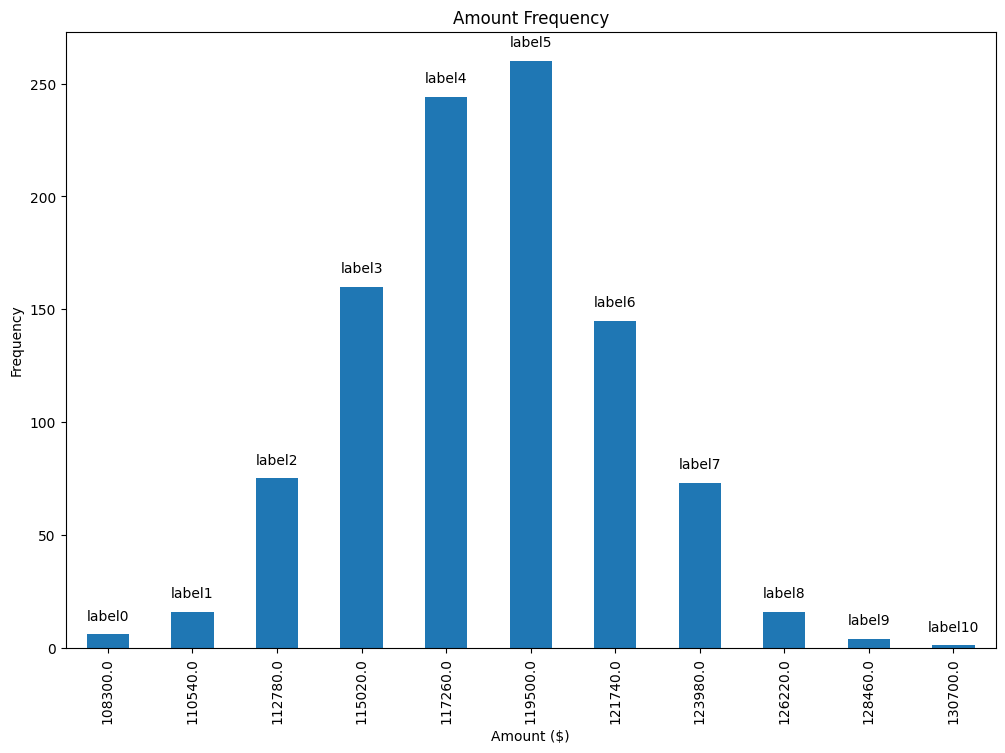

In [89]:
# Bring some raw data.
frequencies = [6, 16, 75, 160, 244, 260, 145, 73, 16, 4, 1]
# In my original code I create a series and run on that,
# so for consistency I create a series from the list.
freq_series = pd.Series(frequencies)

x_labels = [
    108300.0,
    110540.0,
    112780.0,
    115020.0,
    117260.0,
    119500.0,
    121740.0,
    123980.0,
    126220.0,
    128460.0,
    130700.0,
]

# Plot the figure.
plt.figure(figsize=(12, 8))
ax = freq_series.plot(kind="bar")
ax.set_title("Amount Frequency")
ax.set_xlabel("Amount ($)")
ax.set_ylabel("Frequency")
ax.set_xticklabels(x_labels)

rects = ax.patches

# Make some labels.
labels = [f"label{i}" for i in range(len(rects))]

for rect, label in zip(rects, labels):
    height = rect.get_height()
    ax.text(
        rect.get_x() + rect.get_width() / 2, height + 5, label, ha="center", va="bottom"
    )

plt.show()

In [90]:
areas = []
moys = []
x = []
for t in range(jours,0,-1):
    x.append(-t)
    a = area(data.tail(24*t+1).temp.head(25))    # calcul sur 24h
    areas.append(round(a/24,2))
    moys.append(round(data.tail(24*t+1).temp.head(25).mean(),2))
    #print(-t,a)
#print(areas,x)
len(data.tail(24*t+1)),moys

(25,
 [np.float64(20.26),
  np.float64(21.11),
  np.float64(24.68),
  np.float64(26.18),
  np.float64(25.59),
  np.float64(25.71),
  np.float64(28.18),
  np.float64(30.15),
  np.float64(30.87),
  np.float64(26.22),
  np.float64(25.33),
  np.float64(24.1),
  np.float64(23.88),
  np.float64(20.84),
  np.float64(20.16)])

In [91]:
data

,temp,hours,dates,variation,heures,jours
0,13.19,19834.541667,21/04/24 13:00:00,NaN,13,21/04/24
1,12.20,19834.583333,21/04/24 14:00:00,-0.99,14,21/04/24
2,12.29,19834.625000,21/04/24 15:00:00,0.09,15,21/04/24
3,12.42,19834.666667,21/04/24 16:00:00,0.13,16,21/04/24
4,14.54,19834.708333,21/04/24 17:00:00,2.12,17,21/04/24
...,...,...,...,...,...,...
20441,17.18,20686.250000,21/08/26 06:00:00,-0.24,06,21/08/26
20442,17.04,20686.291667,21/08/26 07:00:00,-0.14,07,21/08/26
20443,16.45,20686.333333,21/08/26 08:00:00,-0.59,08,21/08/26
20444,16.99,20686.375000,21/08/26 09:00:00,0.54,09,21/08/26


In [92]:
areas


[20.32,
 21.2,
 24.81,
 26.27,
 25.67,
 25.76,
 28.27,
 30.26,
 31.04,
 26.33,
 25.45,
 24.19,
 23.96,
 20.86,
 20.24]

[Text(-8.0, 0, '-7'),
 Text(-6.0, 0, '-6'),
 Text(-4.0, 0, '-5'),
 Text(-2.0, 0, '-4'),
 Text(0.0, 0, '-3'),
 Text(2.0, 0, '-2'),
 Text(4.0, 0, '-1'),
 Text(6.0, 0, '0'),
 Text(8.0, 0, '1')]

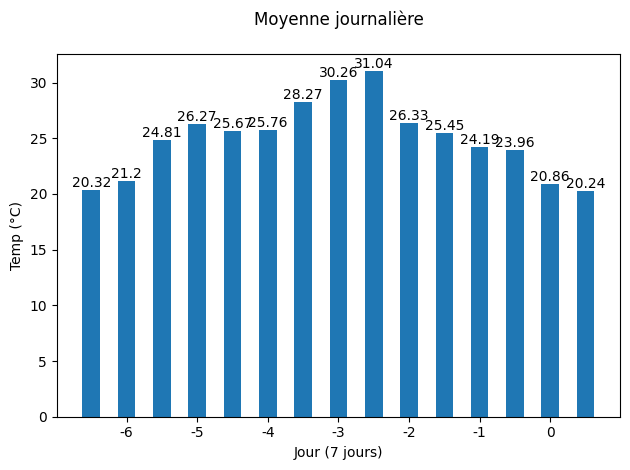

In [93]:
X_axis = np.arange(len(x))-7
fig, ax = plt.subplots()
plt.title("Moyenne journalière\n")
plt.xlabel("Jour (7 jours)")
plt.ylabel("Temp (°C)")
#plt.plot(x,areas,"r")
plt.bar(X_axis,areas,width=0.5)
fig.tight_layout()
# plt.bar(X_axis-0.3,areas,width=0.1)
# plt.bar(X_axis+0.3,moys,width=0.1)
rects = ax.patches

# Make some labels.
labels = [rects[i].get_height() for i in range(len(rects))]

for rect, label in zip(rects, labels):
    height = rect.get_height()
    offset = sign(label)*0.1-0.1
    ax.text(
        rect.get_x() + rect.get_width() / 2, height + offset, label, ha="center", va="bottom"
    )
ax.set_xticklabels(X_axis)


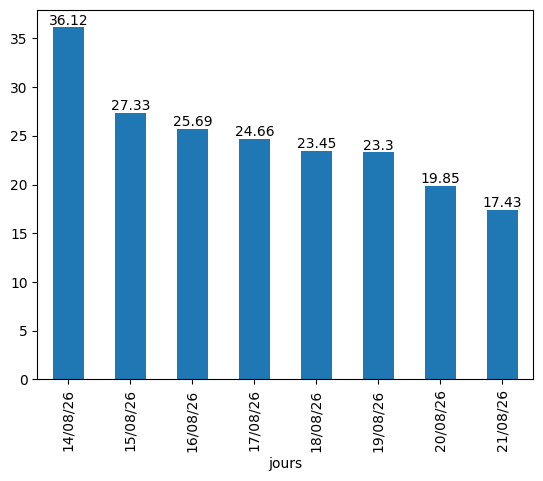

In [94]:
fig, ax = plt.subplots()
df_jours.groupby('jours')['temp'].mean().plot(kind='bar')
rects = ax.patches

# Make some labels.
labels = [round(rects[i].get_height(),2) for i in range(len(rects))]

for rect, label in zip(rects, labels):
    height = rect.get_height()
    offset = sign(label)*0.1-0.1
    ax.text(
        rect.get_x() + rect.get_width() / 2, height + offset, label, ha="center", va="bottom"
    )


In [95]:
labels

[np.float64(36.12),
 np.float64(27.33),
 np.float64(25.69),
 np.float64(24.66),
 np.float64(23.45),
 np.float64(23.3),
 np.float64(19.85),
 np.float64(17.43)]

In [96]:
df = list(data.tail(24).temp.head(24))
df,area(df)

([19.860000000000014,
  21.65000000000004,
  22.79000000000002,
  23.46000000000004,
  24.23000000000001,
  25.220000000000027,
  25.04000000000002,
  25.81,
  23.910000000000025,
  23.07000000000005,
  20.53000000000003,
  19.52000000000004,
  18.98000000000001,
  18.410000000000025,
  17.80000000000001,
  17.350000000000023,
  17.730000000000018,
  17.140000000000043,
  17.420000000000016,
  17.180000000000007,
  17.04000000000002,
  16.450000000000045,
  16.99000000000001,
  18.21000000000004],
 466.75500000000056)

In [97]:
moy = []
for i in range(len(df)-1):
    moy.append((df[i]+df[i+1])/2)
sum(moy)

466.75500000000056

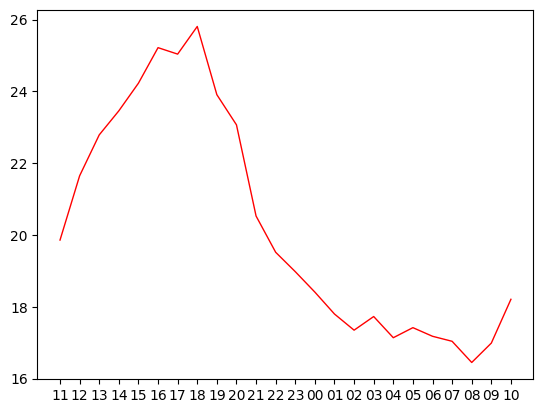

In [98]:
plt.plot(data.tail(24).heures.head(24),data.tail(24).temp.head(24),lw=lw,label=-t,c='red')

In [99]:
data.tail()


,temp,hours,dates,variation,heures,jours
20441,17.18,20686.250000,21/08/26 06:00:00,-0.24,06,21/08/26
20442,17.04,20686.291667,21/08/26 07:00:00,-0.14,07,21/08/26
20443,16.45,20686.333333,21/08/26 08:00:00,-0.59,08,21/08/26
20444,16.99,20686.375000,21/08/26 09:00:00,0.54,09,21/08/26
20445,18.21,20686.416667,21/08/26 10:00:00,1.22,10,21/08/26


In [100]:
chop = data.tail(24).temp
_max, _min = local_min_max(list(chop))
_max,_min,len(_max),len(_min)

([25.220000000000027, 25.81, 17.730000000000018, 17.420000000000016],
 [19.860000000000014,
  25.04000000000002,
  17.350000000000023,
  17.140000000000043,
  16.450000000000045],
 4,
 5)

In [101]:
_diff=[M-m for M,m in zip(_max, _min)]

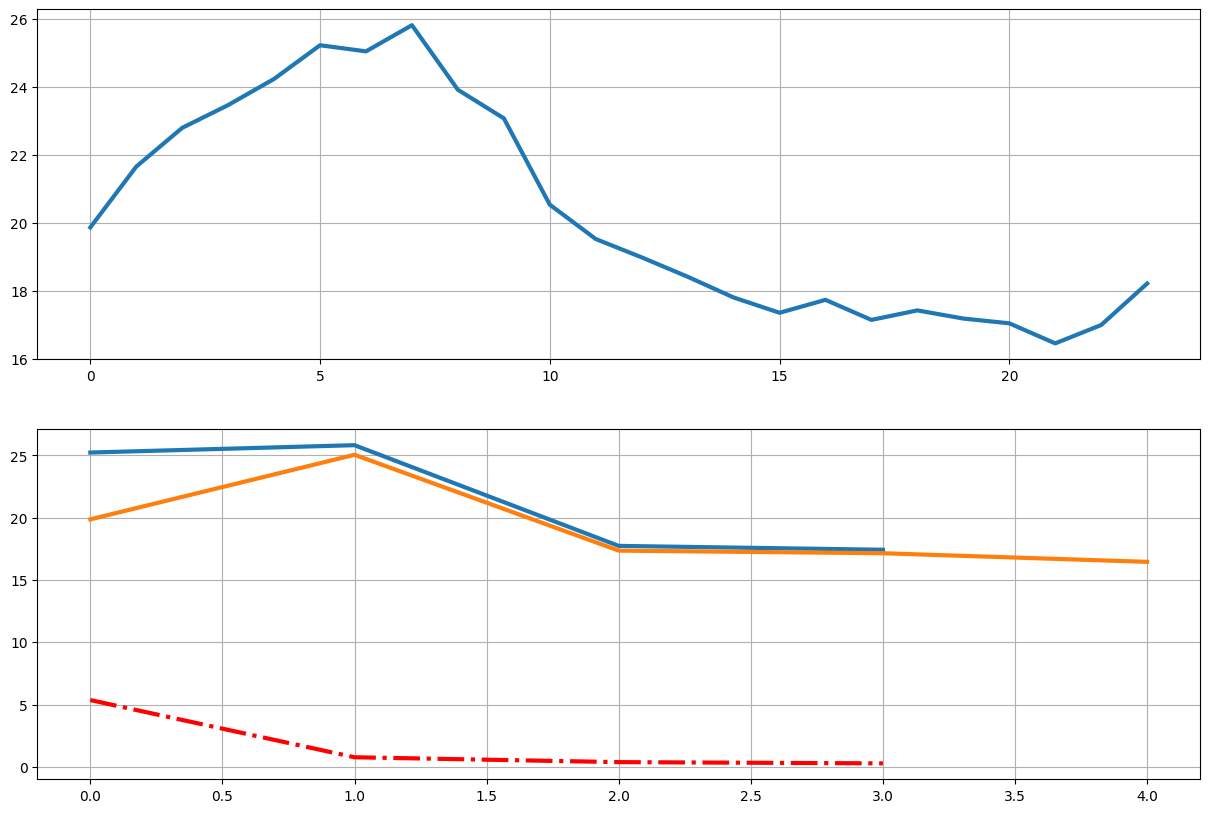

In [102]:
fig, (ax1,ax2) = plt.subplots(2,1)
# the size of A4 paper
fig.set_size_inches(15, 10)
ax1.plot(list(data.tail(24).temp),lw=3)
ax1.grid()
ax2.plot(_max,lw=3)
ax2.plot(_min,lw=3)
ax2.plot(_diff,'r-.',lw=3)
ax2.grid()

[] 0 [1] 1
[] 0 [1] 1


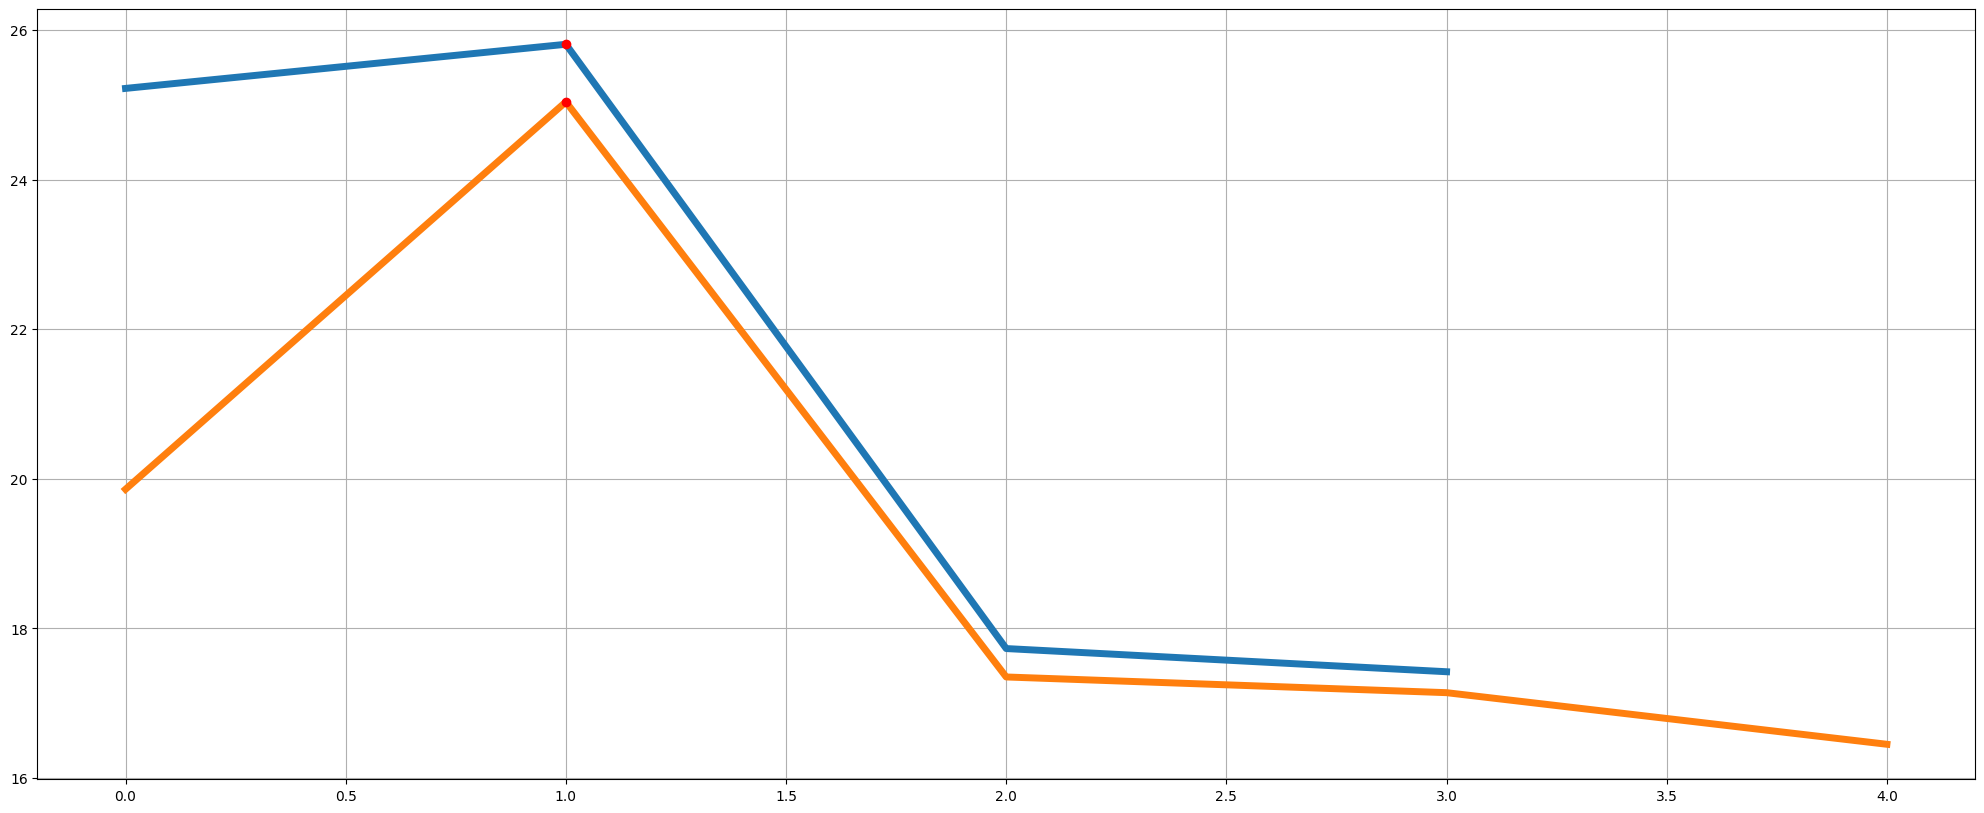

In [103]:
fig, ax = plt.subplots()
# the size of A4 paper
fig.set_size_inches(25, 10)
x =  range(len(_max))
plot_data(x,_max,lw=5)
x =  range(len(_min))
plot_data(x,_min,lw=5)
plt.grid()

In [104]:
liste = [10, 11, 15, 12, 9, 7, 8, 10, 13, 15, 18, 16, 12, 10, 7, 5, 6, 11, 14, 14]
diff(liste)


array([ 1,  4, -3, -3, -2,  1,  2,  3,  2,  3, -2, -4, -2, -3, -2,  1,  5,
        3,  0])

In [105]:
sign(diff(liste))


array([ 1,  1, -1, -1, -1,  1,  1,  1,  1,  1, -1, -1, -1, -1, -1,  1,  1,
        1,  0])

In [106]:
diff(sign(diff(liste)))


array([ 0, -2,  0,  0,  2,  0,  0,  0,  0, -2,  0,  0,  0,  0,  2,  0,  0,
       -1])

In [107]:
diff(sign(diff(liste)))>0


array([False, False, False, False,  True, False, False, False, False,
       False, False, False, False, False,  True, False, False, False])

In [108]:
(diff(sign(diff(liste)))).nonzero()

(array([ 1,  4,  9, 14, 17]),)

# maximas, minimas

[ 5 15] 2 [ 2 10 18] 3


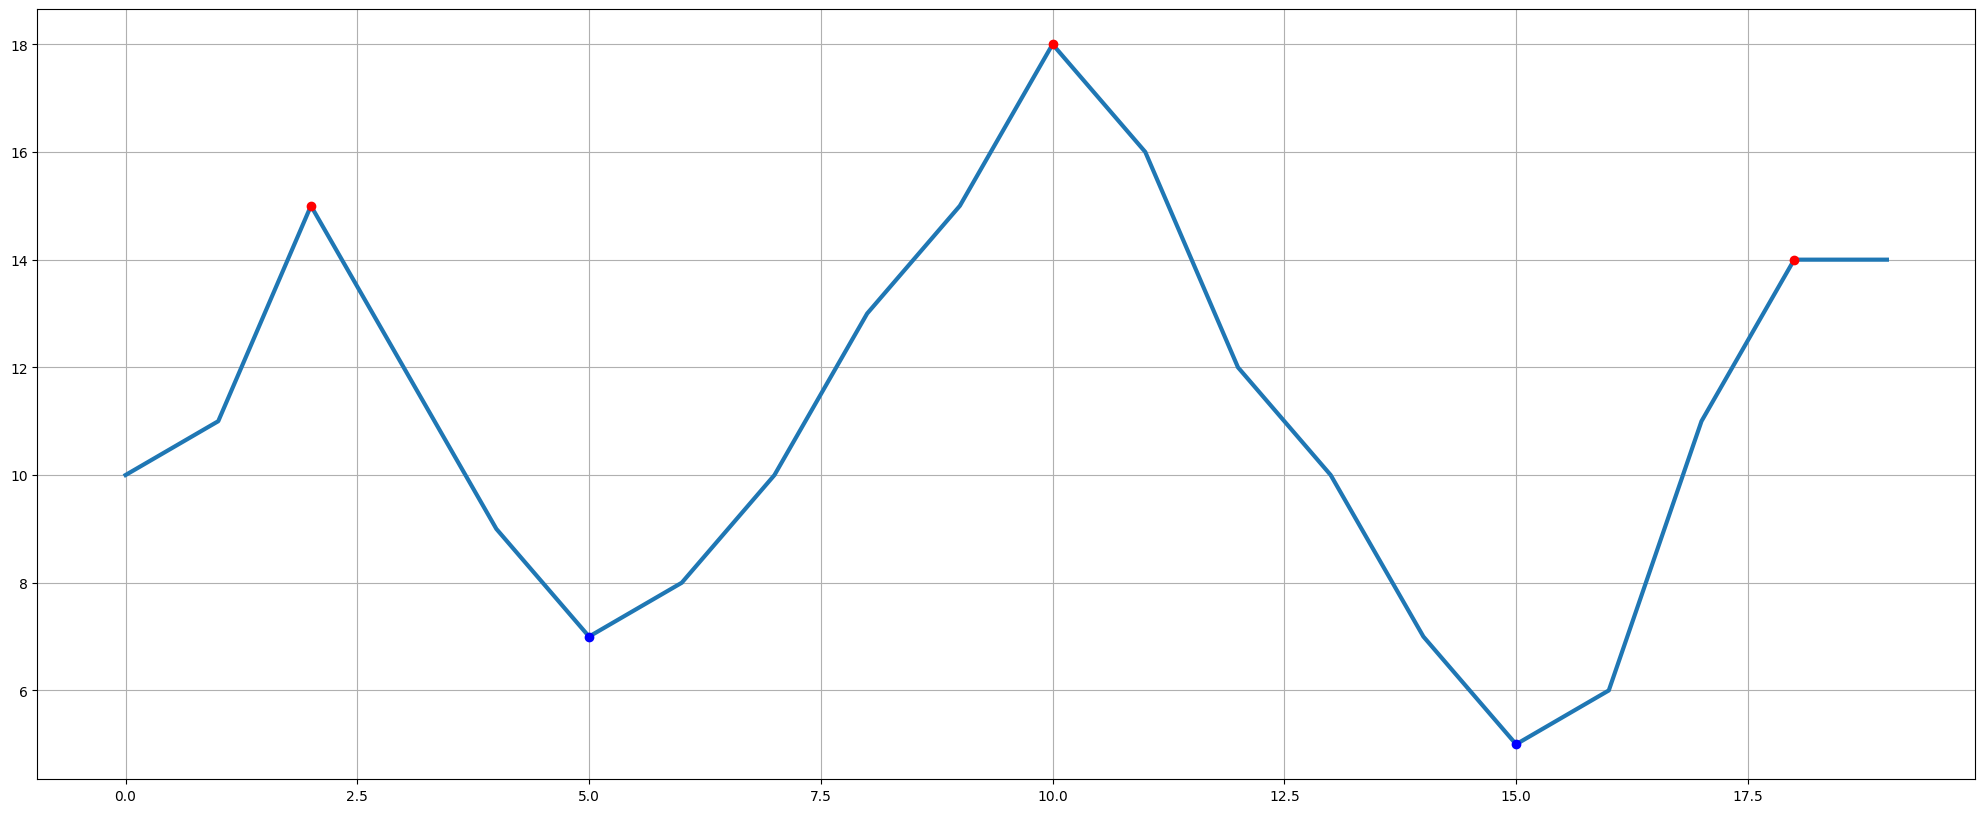

In [109]:
fig, ax = plt.subplots()
# the size of A4 paper
fig.set_size_inches(25, 10)
x = range(len(liste))
_data = liste
plot_data(x, _data)


In [110]:
date_time_str,days,interval

('21/04/24 13:00:00', 15, 12)

In [111]:
df

[19.860000000000014,
 21.65000000000004,
 22.79000000000002,
 23.46000000000004,
 24.23000000000001,
 25.220000000000027,
 25.04000000000002,
 25.81,
 23.910000000000025,
 23.07000000000005,
 20.53000000000003,
 19.52000000000004,
 18.98000000000001,
 18.410000000000025,
 17.80000000000001,
 17.350000000000023,
 17.730000000000018,
 17.140000000000043,
 17.420000000000016,
 17.180000000000007,
 17.04000000000002,
 16.450000000000045,
 16.99000000000001,
 18.21000000000004]

## last records

In [112]:
# 7 jours temp, mean
df = pd.DataFrame(data.tail(7*24)['temp'])
df['mean']= mean_days[-7*24:]
df

,temp,mean
20278,31.27,30.327083
20279,34.28,30.444583
20280,36.80,30.570417
20281,38.22,30.697500
20282,38.63,30.818750
...,...,...
20441,17.18,20.091250
20442,17.04,20.152500
20443,16.45,20.202917
20444,16.99,20.236667


# temperature, moyenne, variation

<Axes: >

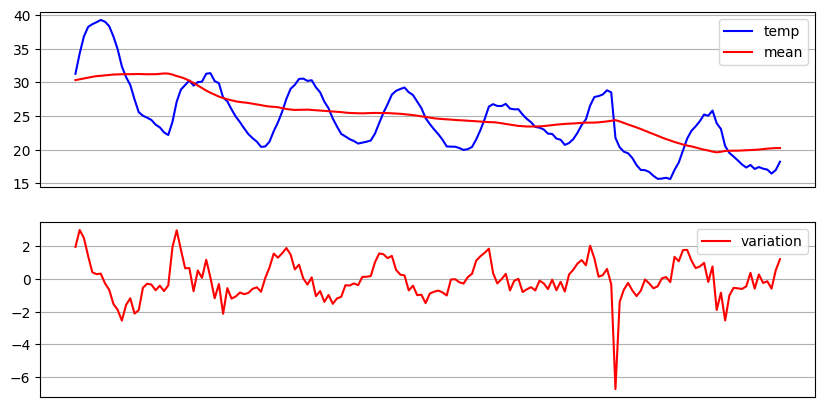

In [113]:
fig, axes = plt.subplots(nrows=2, ncols=1)

# plot temp, mean
df.plot(ax=axes[0],figsize=(10,5),color=['blue','red'],grid=True, legend=True,rot=45,xticks=[])
# 7 jours variation
data.tail(7*24)['variation'].plot(ax=axes[1],figsize=(10,5),color='red',grid=True, legend=True,rot=45,xticks=[])

In [114]:
data.tail(24*7)['temp'].max(),data.tail(24*7)['temp'].min()

(np.float64(39.26000000000005), np.float64(15.640000000000043))

In [115]:
def high_low(n):
    # variation 24 heures il y a n jours
    #n = 0
    l = len(data)
    e = n*24
    s = e+24

    high = round(data[l-s:l-e]['temp'].max(),2)
    low = round(data[l-s:l-e]['temp'].min(),2)
    delta = round(high - low,2)
    return high,low,delta

In [116]:
# max, min, delta sur n jours
n = 30
high_n = []
low_n = []
moy_n =  []
delta_n = []
for k in range(n):
    h,l,d = high_low(n-1-k)
    high_n.append(h)
    low_n.append(l)
    moy_n.append((h+l)/2)
    delta_n.append(d)
    print('J',-(n-1-k),h,l,d)


J -29 25.56 14.75 10.81
J -28 24.66 14.43 10.23
J -27 28.05 16.66 11.39
J -26 30.27 15.69 14.58
J -25 25.78 14.85 10.93
J -24 28.05 15.56 12.49
J -23 33.33 18.88 14.45
J -22 38.32 21.09 17.23
J -21 29.99 19.19 10.8
J -20 30.0 17.44 12.56
J -19 29.43 15.84 13.59
J -18 33.33 20.55 12.78
J -17 37.77 22.5 15.27
J -16 32.53 19.99 12.54
J -15 28.32 17.63 10.69
J -14 26.38 13.16 13.22
J -13 27.13 13.88 13.25
J -12 31.5 17.77 13.73
J -11 33.61 19.12 14.49
J -10 32.49 17.92 14.57
J -9 32.76 18.32 14.44
J -8 35.24 20.43 14.81
J -7 37.8 21.74 16.06
J -6 39.26 22.18 17.08
J -5 31.36 20.41 10.95
J -4 30.55 20.91 9.64
J -3 29.23 19.96 9.27
J -2 26.8 20.71 6.09
J -1 28.82 15.64 13.18
J 0 25.81 16.45 9.36


<Axes: >

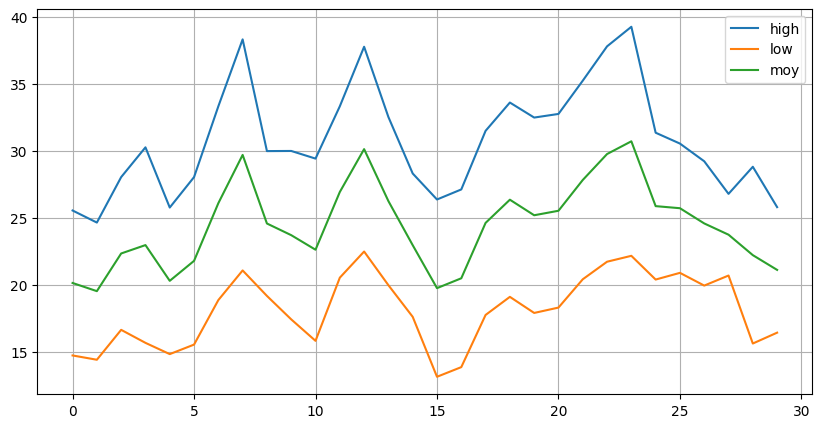

In [117]:
# pandas plot
df1 = pd.DataFrame()
df1['high'] = high_n
df1['low'] = low_n
df1['moy'] = moy_n
df1['delta'] = delta_n
df1[['high','low','moy']].plot(figsize=(10,5),grid=True, legend=True)

In [118]:
_data = list(df1['high'])
_max, _min = local_min_max(_data)
_max


[25.56, 30.27, 38.32, 30.0, 37.77, 33.61, 39.26, 28.82]

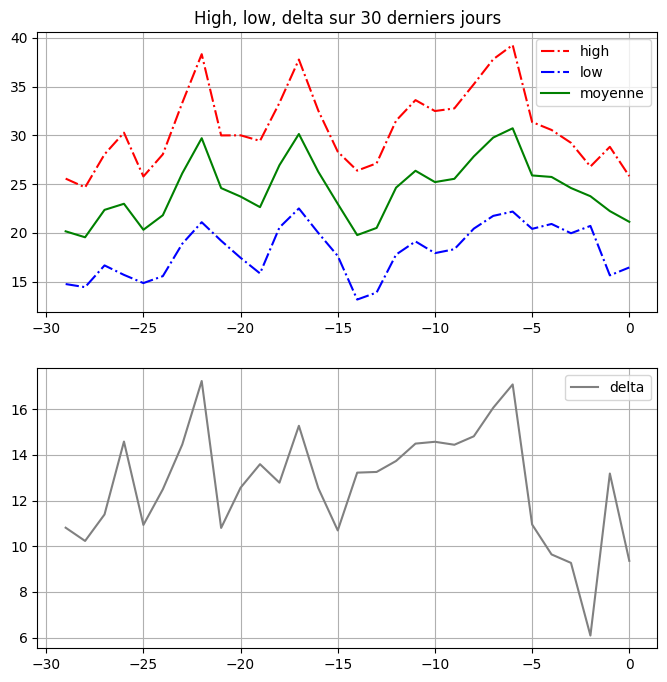

In [119]:
# plot lists
x = range(-29,1,1)
fig, (ax1, ax2) = plt.subplots(2,1)
# the size of A4 paper
fig.set_size_inches(8, 8)
ax1.set_title('High, low, delta sur '+str(n)+' derniers jours')
ax1.plot(x,high_n, '-.',color='red',label='high')
ax1.plot(x,low_n, '-.', color='blue',label = 'low')
ax1.plot(x,moy_n, color='green',label = 'moyenne')
ax1.grid()
ax1.legend()
#moy_n = [(h+l)/2 for h,l in zip(high_n,low_n)]

ax2.plot(x,delta_n,color='grey',label='delta')
ax2.grid()
ax2.legend()

In [120]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20446 entries, 0 to 20445
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   temp       20446 non-null  float64
 1   hours      20446 non-null  float64
 2   dates      20446 non-null  object 
 3   variation  20445 non-null  float64
 4   heures     20446 non-null  object 
 5   jours      20446 non-null  object 
dtypes: float64(3), object(3)
memory usage: 958.5+ KB


In [121]:
data_24 = data.tail(25)[['hours','dates','variation']]
#len(data_24),data_24


In [122]:
# plot X_axis
date_24 = np.array(data.tail(25)['hours'])
#date_24

In [123]:
# inutile ! il faut utiliser le champ data.hours
def mk_date2(data):
    str1, str2 = data_24.head(1)['dates'].values[0] , data_24.tail(1)['dates'].values[0] 
    print(str1,str2)
    return mdates.drange(datetime.strptime(str1, '%d/%m/%y %H:%M:%S'),datetime.strptime(str2, '%d/%m/%y %H:%M:%S'),dt.timedelta(hours=1))
#date_24 = mk_date2(data_24)

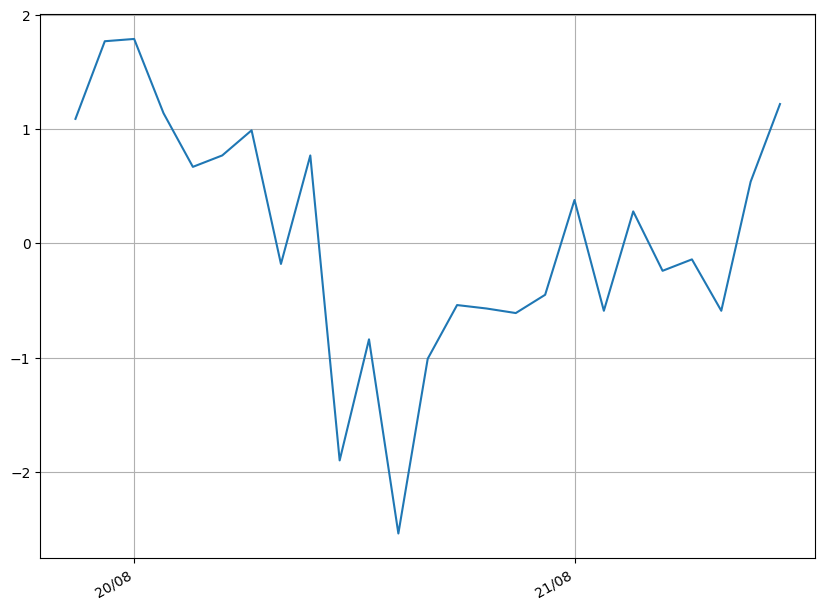

In [124]:
l = len(date_24)
data.tail(l)[['temp','variation']]
var = data.tail(l)[['variation']].values

fig, ax = plt.subplots()
fig.set_size_inches(10, 8)
plt.plot(date_24,var)
format_date()
#plt.grid()

In [125]:
w = int(24*days)
days,data.tail(w)['temp'].max(), data.tail(w)['temp'].min()


(15, np.float64(39.26000000000005), np.float64(13.160000000000023))

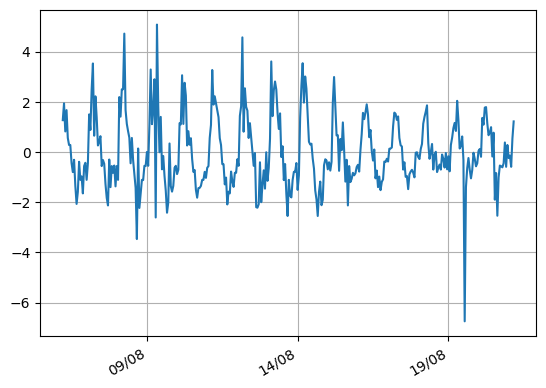

In [126]:
#data['variation'].tail(w).plot()
plt.plot(data['hours'].tail(w),data['variation'].tail(w))
format_date(24)

### date pour les temp max, min

In [127]:
d_max = data.tail(w)['temp'].max()
d_max, data[data['temp']==data.tail(w)['temp'].max()]['dates']

(np.float64(39.26000000000005),
 20284    14/08/26 17:00:00
 Name: dates, dtype: object)

In [128]:
d_min = data.tail(w)['temp'].min()
d_min, data[data['temp']==data.tail(w)['temp'].min()]['dates']

(np.float64(13.160000000000023),
 552      14/05/24 13:00:00
 3590     18/09/24 03:00:00
 4712     03/11/24 21:00:00
 9426     19/05/25 07:00:00
 17228    09/04/26 09:00:00
 17444    18/04/26 09:00:00
 20106    07/08/26 07:00:00
 Name: dates, dtype: object)

In [129]:
data.tail(w)['temp'].describe()

count    360.000000
mean      24.974500
std        5.520287
min       13.160000
25%       20.925000
50%       24.570000
75%       28.892500
max       39.260000
Name: temp, dtype: float64

In [130]:
from  datetime import datetime
#matplotlib.dates.date2num(hours)
#then.isoformat(),round(temp[-1],2)
today = datetime.now()




In [131]:
data.tail(1)["dates"].values[0].split(':')[0]


'21/08/26 10'

In [132]:
# current date and time
ts = datetime.timestamp(today)
ts

1787302434.016401